---
title: "🗓️ Week 03 - Linear Regression to Classification"
subtitle: "DS202W: Data Science for Social Scientists"
author: "Dr. Ghita Berrada"
date: "03 February 2026"
format: 
  html:
    page-layout: full
    toc: true
    toc-depth: 3
    self-contained: true
jupyter: python3
engine: jupyter
---

# Welcome to Week 03! 🎉

**Last week**, we worked through local authority unemployment prediction and covered:

- Data loading and initial exploration
- Understanding missingness mechanisms (MCAR, MAR, MNAR)
- Train-test splitting
- Feature selection and correlation analysis

**We stopped before model fitting and evaluation.** Today we'll:

1. Complete the regression workflow with ONS unemployment data
2. Apply regularization (Ridge, Lasso, Elastic Net)
3. Properly evaluate models and understand overfitting
4. Transition to **classification** with the same dataset
5. Handle the **perfect separation problem**

---

## ⚙️ Setup

In [8]:
#| label: setup
#| warning: false

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error, 
    mean_squared_error, 
    r2_score,
    confusion_matrix,
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)
from sklearn.impute import KNNImputer
import warnings 
# Set random seed for reproducibility
np.random.seed(42)

# Plotting style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

---

# 🎯 Learning Objectives

**Part 1: Completing Regression (60 minutes)**

- Fit linear regression models (OLS, Ridge, Lasso, Elastic Net)
- Understand and interpret coefficients after scaling
- Evaluate models with multiple metrics (MAE, RMSE, R²)
- Diagnose overfitting/underfitting with train vs. test metrics
- Use residual plots for model diagnostics

**Part 2: Introduction to Classification (45 minutes)**

- Transform regression problem into classification
- Understand when and why classification is needed
- Fit logistic regression models
- Interpret logistic regression coefficients (odds ratios)
- Recognize and handle **perfect separation**

---

# Part 1: Completing the Regression Case Study 📊

## 1.1 Loading and Preparing the Data

Last week we prepared the ONS local authority unemployment data. Let's reload it and continue from where we left off:

In [9]:
from pathlib import Path
print(Path("D:/Codes/DS202/data/ons_local_authority_dataset.csv").exists())

True


In [10]:
#| label: load-data

# Load the data (adjust path as needed)
# This is the cleaned ONS local authorities dataset from W02
ons_data = pd.read_csv(
    "..\data\ons_local_authority_dataset.csv",
    skipinitialspace=True)

# Quick inspection
print(f"Dataset shape: {ons_data.shape}")
print(f"\nFirst few rows:")
ons_data.head()

Dataset shape: (471, 20)

First few rows:


<>:6: SyntaxWarning: invalid escape sequence '\d'
<>:6: SyntaxWarning: invalid escape sequence '\d'
C:\Users\RobertC\AppData\Local\Temp\ipykernel_13524\694797641.py:6: SyntaxWarning: invalid escape sequence '\d'
  "..\data\ons_local_authority_dataset.csv",


,Area code,population_density,pct_age_16_64,modelled_unemployment_rate,gdhi_per_head,median_weekly_pay,inward_fdi,active_businesses,business_births,business_deaths,high_growth_businesses,cancer_stage1_2,gigabit_broadband,coverage_4g,coverage_5g,premises_below_30mbps,travel_time_bike,travel_time_car,travel_time_pt_walk,Area name
0,E06000001,984.0,61.24,7.5,16203.0,442.4,NaN,2535.0,12.228797,11.834320,2.173913,50.72464,96.0,99.99,99.62,1.3,10.070582,7.790802,12.900208,Hartlepool
1,E06000002,2638.0,62.37,7.6,15672.0,397.6,NaN,3865.0,15.135834,12.419146,3.846154,56.13126,94.7,100.00,100.00,1.9,11.335077,8.457817,15.372879,Middlesbrough
2,E06000003,558.0,59.23,5.6,16436.0,397.2,NaN,3425.0,11.094891,11.386861,4.545455,52.20820,90.2,99.19,93.72,1.8,11.103287,8.066075,13.259369,Redcar and Cleveland
3,E06000004,961.0,61.77,5.7,17141.0,453.5,NaN,6085.0,12.900575,11.339359,3.703704,52.20126,91.8,99.99,98.12,3.7,10.050299,7.818049,13.181988,Stockton-on-Tees
4,E06000005,539.0,61.03,6.1,17636.0,440.4,NaN,3525.0,12.624113,12.340426,2.564103,56.27706,91.0,99.99,96.90,2.6,9.488321,7.457621,11.023619,Darlington


Modelled unemployment rate summary:
count    371.000000
mean       3.695957
std        1.173311
min        1.700000
25%        2.800000
50%        3.600000
75%        4.400000
max        8.200000
Name: modelled_unemployment_rate, dtype: float64


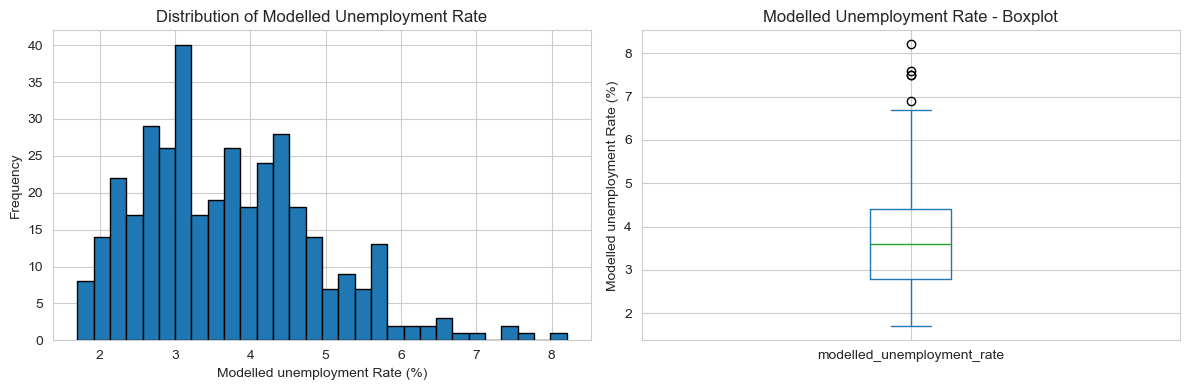

In [11]:
#| label: check-outcome

# Check the outcome variable distribution
print("Modelled unemployment rate summary:")
print(ons_data['modelled_unemployment_rate'].describe())

# Visualize
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(ons_data['modelled_unemployment_rate'], bins=30, edgecolor='black')
plt.xlabel('Modelled unemployment Rate (%)')
plt.ylabel('Frequency')
plt.title('Distribution of Modelled Unemployment Rate')

plt.subplot(1, 2, 2)
ons_data['modelled_unemployment_rate'].plot(kind='box')
plt.ylabel('Modelled unemployment Rate (%)')
plt.title('Modelled Unemployment Rate - Boxplot')

plt.tight_layout()
plt.show()

---

## 1.2 Missingness Recap

From last week, we identified features with missing values. Let's summarise missingness before proceeding.:

In [12]:
#| label: select-features

outcome_col = 'modelled_unemployment_rate'

# Check for missing values
cols = ons_data.columns

# Calculate both
missing_count = ons_data[cols].isnull().sum()
missing_pct = (ons_data[cols].isnull().mean() * 100).round(2)

# Combine into a report table
missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Percentage (%)': missing_pct
})

print(missing_report.sort_values(by='Percentage (%)', ascending=False))

                            Missing Count  Percentage (%)
inward_fdi                            446           94.69
cancer_stage1_2                       206           43.74
travel_time_car                       108           22.93
travel_time_pt_walk                   108           22.93
travel_time_bike                      108           22.93
modelled_unemployment_rate            100           21.23
median_weekly_pay                      80           16.99
gdhi_per_head                          59           12.53
population_density                     58           12.31
pct_age_16_64                          58           12.31
Area name                              58           12.31
premises_below_30mbps                  56           11.89
coverage_4g                            56           11.89
coverage_5g                            56           11.89
gigabit_broadband                      56           11.89
high_growth_businesses                 23            4.88
business_birth

We mentioned that we wouldn't use features with excessive missingness (e.g `inward_fdi`).
---

## 1.3 Train-Test Split

**Critical reminder**: We split BEFORE imputation to avoid data leakage!

In [13]:
# 1. Clean the data: Drop rows where the outcome_col is missing
# It's safer to create a cleaned copy to avoid SettingWithCopy warnings later
ons_data_cleaned = ons_data.dropna(subset=[outcome_col]).copy()

# 2. Define features (using the cleaned dataframe)
feature_cols = ons_data_cleaned.columns.drop([
    outcome_col,
    'Area name',
    'Area code',
    'inward_fdi'  # excessive missingness
])

# 3. Separate features and outcome from the cleaned data
X = ons_data_cleaned[feature_cols]
y = ons_data_cleaned[outcome_col]

# 4. Split 70-30
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Rows dropped due to missing outcome: {len(ons_data) - len(ons_data_cleaned)}")
print(f"Final Training set size: {X_train.shape[0]}")
print(f"Final Test set size: {X_test.shape[0]}")

Rows dropped due to missing outcome: 100
Final Training set size: 259
Final Test set size: 112


We mentioned last week that the train-test split must be done before imputation and scaling to avoid data leakage. Since this is a cross-sectional dataset, there are no temporal dependencies that would require a chronological split. While the observations represent geographical units (Local Authorities), we have utilized a random train-test split under the assumption that the included features sufficiently capture the socio-economic and demographic characteristics of each area. By treating each Local Authority as an independent observation, a random split ensures that both the training and testing sets are representative of the full diversity of local government types across the country. This approach allows us to effectively evaluate the model's generalization performance across different types of Local Authorities without introducing bias from geographical clustering.
We also mentioned last week that **imputation and scaling must be fit on training data only**. Let's implement that now.

🏡 **TAKE-HOME EXERCISE**:
Can you figure out how to create a stratified training–test split so that both sets are geographically balanced, rather than being split purely at random across UK local authorities?

💡 *Hint*:
Think about re-introducing a geographic grouping variable (e.g. region or country within the UK) before splitting, and ask yourself: what exactly should be balanced across the train and test sets?

---

## 1.4 Feature Scaling (Mandatory Here, Good Practice Overall)

**⚠️ Important principle:**
👉 **Always fit preprocessing steps on the training data only.**

**Why?**
Preprocessing steps (such as scaling or imputation) estimate quantities from the data.
If these are computed using the full dataset, information from the test set leaks into training, resulting in **over-optimistic model performance**.

---

### Why scaling is *mandatory* at this stage

In this workflow, **missing values are imputed using KNN**.

* KNN imputation is **distance-based**
* Distances are meaningless if features are on very different scales
* Therefore, **scaling *before* KNN imputation is not optional**

👉 Without scaling, the imputation itself would be distorted, regardless of the model used later.

---

### Why scaling would still be a good idea *anyway*

Even if we were **not** using KNN imputation, scaling would still be necessary or strongly recommended because the modelling steps that follow include **linear and regularised regression models**.

* **Ridge, LASSO, Elastic Net** penalise coefficient magnitudes
  → scaling ensures penalties are applied **fairly across features**
* **Optimisation stability** improves when features are on comparable scales
* **Interpretation** of coefficient sizes becomes more meaningful

So in this pipeline:

* **Scaling is required now** (because of KNN imputation), and
* **Scaling is appropriate later** (because of regularised linear models)

---

In [14]:
#| label: scaling
# Initialize the scaler
scaler = StandardScaler()

# Fit on training data ONLY
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

# Apply the same transformation to the test data
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Scaling complete!")

Scaling complete!


---

### 🧠 Key takeaway

> In a modelling pipeline, **earlier choices constrain later ones**:
> once we introduce a distance-based step (KNN imputation), scaling becomes unavoidable — and it remains good practice for the models that follow.

Here you go — a **self-contained K-NN imputation section** that slots neatly after scaling, keeps the **important principle**, and makes the dependency explicit without re-teaching KNN.

---

## 1.5 K-Nearest Neighbours (K-NN) Imputation

**⚠️ Important principle:**
👉 **Always fit the imputer on the training data only.**

**Why?**
K-NN imputation identifies “similar” observations using **distances in feature space**.
If the imputer were fit on the full dataset, information from the test set would influence the imputed values in the training set, resulting in **data leakage** and overly optimistic performance.

---

### Why scaling comes *before* K-NN imputation

* K-NN imputation is **distance-based**
* Distances are sensitive to feature scale
* Therefore, **features must be scaled before applying K-NN imputation**

This makes scaling **mandatory** at this stage of the pipeline.

---

In [15]:
#| label: knn_imputation


# Initialize the K-NN imputer
imputer = KNNImputer(n_neighbors=5)

# Fit on training data ONLY
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_scaled),
    columns=X_train_scaled.columns,
    index=X_train_scaled.index
)

# Apply the same imputation to the test data
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_scaled),
    columns=X_test_scaled.columns,
    index=X_test_scaled.index
)

print("K-NN imputation complete!")
print("Missing values after imputation:")
print(X_train_imputed.isnull().sum().sum(), "in training")
print(X_test_imputed.isnull().sum().sum(), "in test")

K-NN imputation complete!
Missing values after imputation:
0 in training
0 in test


:::callout-tip

🔍 **Why do we convert the imputer output back into a DataFrame?**

`KNNImputer` (like most `scikit-learn` preprocessors) returns a `NumPy` array, which does not keep:

- column names

- row indices

Wrapping the output in a `pandas.DataFrame` allows us to:

- preserve feature names, so we know which variables are which

- preserve row alignment, ensuring predictions still correspond to the correct local authorities

- keep compatibility with downstream steps (plotting, coefficient inspection, model fitting)

Without this step, we would lose important metadata and make our analysis harder to interpret and debug.
:::

---

### 🧠 Key takeaway

> Once a **distance-based preprocessing step** is introduced (such as K-NN imputation), **scaling is no longer optional** — and it aligns naturally with the regularised linear models used later in the workflow.


---

## 1.6. Linear Regression Models

We now fit **three linear models**, each serving a different conceptual purpose.

---

### 1.6.1 Model 1: Univariate baseline

We start simple.

> *How much unemployment variation can income alone explain?*

In [16]:
#| label: model-univariate

model_uni = LinearRegression()

X_train_gdhi = X_train_imputed[["gdhi_per_head"]]
X_test_gdhi  = X_test_imputed[["gdhi_per_head"]]

model_uni.fit(X_train_gdhi, y_train)

# Get predictions
y_train_pred_uni = model_uni.predict(X_train_gdhi)
y_test_pred_uni = model_uni.predict(X_test_gdhi)

print(f"Univariate model coefficient: {model_uni.coef_[0]:.4f}")
print(f"Interpretation: A one–standard deviation increase in GDHI per head is associated with an average " + ("decrease" if model_uni.coef_[0]<0 else "increase") + f" of about {abs(model_uni.coef_[0]):.4f} percentage points in the modelled unemployment rate.")

Univariate model coefficient: -0.3381
Interpretation: A one–standard deviation increase in GDHI per head is associated with an average decrease of about 0.3381 percentage points in the modelled unemployment rate.


*Note: GDHI per head was standardised before modelling, so the coefficient corresponds to a one–standard deviation change in income. Without standardisation, the coefficient would correspond to a one-unit change in GDHI per head (measured in pounds).*

**Why this model matters**

- **Establishes a baseline**
Provides a simple reference point against which more complex models can be compared. Any improvement later should be judged relative to this benchmark.

- **Demonstrates the limits of single-variable explanations**
Income alone captures some variation in unemployment, but many relevant factors are omitted. This model makes those limitations explicit.

- **Prevents over-interpreting complex models later**
Starting simple helps distinguish genuinely informative predictors from patterns that only emerge once many variables are included.

- **Describes association, not causation**
The estimated relationship reflects correlation: income and unemployment may both be influenced by demographics, labour-market structure, infrastructure, or regional context.

*How much of this apparent relationship (i.e relationship between GDHI per head and modelled unemployment rate) remains once we account for demographics, labour-market structure, infrastructure, and regional characteristics?*

---

### 1.6.2 Model 2: Multivariate linear regression (OLS)

In [17]:
#| label: model-ols

model_ols = LinearRegression()
model_ols.fit(X_train_imputed, y_train)

# Get predictions
y_train_pred_ols = model_ols.predict(X_train_imputed)
y_test_pred_ols = model_ols.predict(X_test_imputed)

print("OLS coefficients:")
coef_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Coefficient': model_ols.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coef_df.to_string(index=False))

OLS coefficients:
               Feature  Coefficient
   travel_time_pt_walk    -0.702618
    population_density     0.421308
    travel_time_bike       0.367956
     median_weekly_pay    -0.347284
    business_births        0.308810
     travel_time_car       0.207704
     gigabit_broadband     0.199951
         gdhi_per_head    -0.193044
    business_deaths        0.144794
 premises_below_30mbps     0.122424
           coverage_5g    -0.106214
high_growth_businesses    -0.054778
         pct_age_16_64    -0.047078
    cancer_stage1_2       -0.031563
     active_businesses     0.027545
           coverage_4g     0.021894


*Note: All predictors were standardised before modelling, so coefficient magnitudes are directly comparable across variables.*

This estimates **partial effects**:

* Each coefficient answers:
  > *What is the association with unemployment, holding other variables constant — that is, comparing areas that are similar in all other measured respects?*


**Interpretation example**:

Compared to the univariate model, the coefficient on GDHI per head is smaller in magnitude once other variables are included. This suggests that the negative association between income and unemployment observed earlier was **partly capturing broader area characteristics**—such as population density, labour-market structure, transport accessibility, and economic activity—that are correlated with income.

In the multivariate model, variables related to **accessibility and urban structure** (e.g. travel time by public transport, population density) exhibit larger coefficients in absolute value. This indicates that, holding income and other factors constant, differences in connectivity and spatial structure are more strongly associated with unemployment rates than income alone.

Importantly, these coefficients represent **conditional associations, not causal effects**. Each coefficient answers the question: *among local authorities that are similar in all other measured characteristics, how does the average unemployment rate differ as one variable changes?*

For example, the negative coefficient on public transport travel time does not mean that reducing travel times would directly reduce unemployment. Instead, local authorities with shorter travel times typically share a wider set of advantages—such as denser labour markets, better job matching, and greater access to services—which are themselves associated with lower unemployment. The model reflects this shared context and correlation structure, rather than isolating a direct causal effect of transport accessibility. As a result, coefficients from this model should not be interpreted as estimates of the impact of policy interventions.

Overall, this model shows that the income–unemployment relationship becomes **less prominent** once we account for multiple dimensions of local context, reinforcing the idea that **unemployment is a multifactorial outcome rather than something driven by a single economic indicator**.

**Important caveat**:

- Some predictors are likely to be correlated with each other (e.g. income, pay, business activity, and infrastructure).

- As a result, individual coefficients may be unstable or sensitive to which variables are included.

- Interpretation should focus on patterns and signs, not precise numerical values.


---

## 1.7 Evaluation metrics

### Training vs Test Metrics (Overfitting and Underfitting)

#### **Conceptual framework**

**Training metrics answer:**

> "How well does the model fit the data it was trained on?"

**Test metrics answer:**

> "How well does the model generalise to new data?"

Only **together** can they diagnose model behaviour.

---

**Interpreting the gap:**

| Pattern                        | Interpretation                       |
|-------------------------------|--------------------------------------|
| Poor train, poor test          | **Underfitting** (model too simple)  |
| Excellent train, poor test     | **Overfitting** (model too complex)  |
| Similar, moderate performance  | **Good generalisation**              |
| Similar, excellent performance | Rare in social data (be suspicious!) |

---

### **Why this matters in social science**

Social data:

* Is noisy
* Has weak signals  
* Contains measurement error

A model that fits *too well* is usually fitting **noise**, not structure.

---

### Evaluation metrics: what they measure (and what they don't)

We now explain each metric in more detail.

#### **Mean Absolute Error (MAE)**

$$
\text{MAE} = \frac{1}{n} \sum |y - \hat{y}|
$$

**Interpretation:**

- Average absolute prediction error

- Expressed in percentage points of unemployment (i.e. in the unit of the variable predicted)

- Easy to explain to non-technical audiences

- The lower, the better

- Can be read as: “On average, how far off are our predictions?”
  
- *Example*: an MAE of 0.7 means that, on average, the predicted unemployment rate for a local authority is about 0.7 percentage points higher or lower than the true value.

**Pros:**

- Robust to outliers

- Directly interpretable

- Each observation contributes linearly to the final error

**Cons:**

- Treats small and large errors equally

- Does not distinguish between many small mistakes and a few large ones

---

#### **Root Mean Squared Error (RMSE)**

$$
\text{RMSE} = \sqrt{\frac{1}{n} \sum (y - \hat{y})^2}
$$

**Interpretation:**

- Typical size of prediction error

- Penalises large mistakes more heavily

- Also expressed in percentage points of unemployment (i.e. in the unit of the variable predicted)

- The lower, the better

- Can be read as: “How large are errors when large mistakes matter?”

**Pros:**

- Sensitive to large errors

- Highlights models that occasionally make very poor predictions. *Example:* two models may have the same MAE, but if one occasionally misses unemployment by 2–3 percentage points, its RMSE will be much higher.

- Useful when large mistakes are particularly costly or undesirable

**Cons:**

- Less intuitive than MAE

- Can be dominated by a small number of extreme errors
  
---

#### **R² (Coefficient of Determination)**

$$
R^2 = 1 - \frac{\text{Residual variance}}{\text{Total variance}}
$$

**Interpretation:**

- Share of outcome variance explained by the model

- Indicates how much variation in unemployment rates is captured by the predictors

- Not a measure of predictive accuracy

- Can be misleading out of sample

- The higher, the better (closer to 1) - in theory but beware of very high values in practice! In social science applications, extremely high R² values are unusual. Very high R² may indicate that the model is using information that would not be available in practice (data leakage), that predictors are mechanically related to the outcome, or that the model is overfitting idiosyncratic patterns in the data. High R² should therefore prompt careful scrutiny rather than celebration.

- *Example*: an R² of 0.5 means that about half of the observed variation in unemployment rates across local authorities is captured by the model, while the remaining half is left unexplained.

Key warning:

> A high R² does not imply good prediction. R² increases mechanically with the number of predictors (even irrelevant ones).

In social science:

- Moderate R² (0.2–0.4) is common

- Very high R² should raise concerns (potential leakage or overfitting)

- Low R² does not necessarily imply a useless model if prediction errors are small

In practice, MAE and RMSE are usually more informative for assessing predictive performance, while R² is better viewed as a descriptive measure of explained variation.


---

:::callout-note

### 📌 Beyond R²: why alternatives are needed (and when to use them)

R² is widely reported, but it has important **limitations**. It increases mechanically as more predictors are added, does not directly measure predictive accuracy, and can give a **misleading impression of model quality**—especially when comparing models of different complexity or assessing performance on new data.
For these reasons, several alternatives exist, each designed to address a specific shortcoming of plain R².

---

### **Plain R²**

**What it answers:**

> *How much of the variation in the outcome does the model explain in this dataset?*

**Where to use it:**

* ✔ **Training set** (descriptive)
* ⚠️ **Test set** (with caution)

**Why:**
R² is defined relative to the variance of the outcome *in the dataset on which it is computed*. On the training set, it describes how well the model fits the observed data. On the test set, however, the outcome variance may differ, and R² can change simply because the test sample is different—not because the model is better or worse. For this reason, test-set R² should not be treated as a primary measure of predictive performance.

---

### **Adjusted R²**

**What it fixes:**

> Penalises unnecessary model complexity.

**Where to use it:**

* ✔ **Training set only**

**Why:**
Adjusted R² explicitly depends on the **number of predictors** and the **sample size used to estimate the model**. It is designed to evaluate whether adding variables improves *in-sample explanatory power*. On the test set, these assumptions no longer hold, and adjusted R² has **no meaningful interpretation**.

---

### **Predicted R²**

**What it fixes:**

> Focuses explicitly on generalisation to new data.

**Where to use it:**

* ✔ **Test set** (or via cross-validation)

**Why:**
Predicted R² compares test-set prediction errors to the variability in the outcome, effectively asking whether the model performs better than a simple baseline when predicting unseen data. Because it is explicitly constructed to assess **out-of-sample performance**, it is the appropriate R²-type measure for the test set.

---

### **Interpreting gaps between R² measures**

The **gaps between these metrics are often more informative than their absolute values**:

* **R² ≫ Adjusted R²**
  → Many predictors add little real explanatory value.

* **Adjusted R² ≫ Predicted R²**
  → The model fits the training data well but does **not generalise**.

* **All three values similar**
  → Explanatory power is stable and likely to carry over to new data.

In social science, such gaps are common and should prompt **careful interpretation**, not automatic rejection of the model.

---

### 🧪 Python code outline

```python
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Training R²
r2_train = r2_score(y_train, y_train_pred_ols)

# Adjusted R² (training only)
n = X_train_imputed.shape[0]
p = X_train_imputed.shape[1]
adj_r2 = 1 - (1 - r2_train) * (n - 1) / (n - p - 1)

# Predicted R² (test data)
y_train_mean = np.mean(y_train)
pred_r2 = 1 - (
    mean_squared_error(y_test, y_test_pred_ols) /
    mean_squared_error(y_test, np.repeat(y_train_mean, len(y_test)))
)

print(f"R² (train): {r2_train:.3f}")
print(f"Adjusted R² (train): {adj_r2:.3f}")
print(f"Predicted R² (test): {pred_r2:.3f}")
```

If you run this code, you should get the following results:

```python

R² (train): 0.570
Adjusted R² (train): 0.542
Predicted R² (test): 0.468

```

Here's how to interpret these results:


* **R² (train) = 0.570**
  On the training data, the model explains about **57% of the variation** in unemployment rates across local authorities. This reflects how well the model fits the data it was estimated on.

* **Adjusted R² (train) = 0.542**
  After accounting for the number of predictors, the explained variation drops slightly to **about 54%**. The relatively small difference between R² and adjusted R² suggests that most predictors contribute meaningful explanatory power, and that the model is not inflated purely by unnecessary variables.

* **Predicted R² (test) = 0.468**
  On new, unseen data, the model explains roughly **47% of the variation** in unemployment rates. This indicates that a substantial portion of the model’s explanatory power **carries over to the test set**, though some performance is lost compared to the training data.

**What the gaps tell us**

* The gap between **R² and adjusted R²** is modest (≈ 0.03), suggesting **limited over-reliance on extra predictors**.
* The drop from **adjusted R² to predicted R²** (≈ 0.07) indicates **some overfitting**, but not severe: the model fits the training data better than new data, yet still generalises reasonably well.

**Overall takeaway**

> The model captures a meaningful share of the variation in unemployment and retains most of its explanatory power on new data, with only a moderate loss in performance. This pattern is consistent with a model that is **complex enough to be informative**, but **not so complex that it fails to generalise**.


---

### 🧠 Takeaway

> Some metrics describe **how well a model fits the data it was trained on**, while others are designed to assess **how well it will perform on new data**. Using a metric on the wrong dataset can lead to misleading conclusions.

See [https://statisticsbyjim.com/regression/interpret-adjusted-r-squared-predicted-r-squared-regression/](https://statisticsbyjim.com/regression/interpret-adjusted-r-squared-predicted-r-squared-regression/) for further discussion of adjusted and predicted R².
:::


For more resources on R² and its interpretation, see:
- [https://statisticsbyjim.com/glossary/coefficient-of-determination/](https://statisticsbyjim.com/glossary/coefficient-of-determination/)
- [https://statisticsbyjim.com/regression/interpret-r-squared-regression/](https://statisticsbyjim.com/regression/interpret-r-squared-regression/)
- [https://statisticsbyjim.com/regression/r-squared-too-high/](https://statisticsbyjim.com/regression/r-squared-too-high/)
- [https://statisticsbyjim.com/regression/how-high-r-squared/](https://statisticsbyjim.com/regression/how-high-r-squared/)
- [https://statisticsbyjim.com/regression/standard-error-regression-vs-r-squared/](https://statisticsbyjim.com/regression/standard-error-regression-vs-r-squared/)



:::callout-tip

### Metrics summary

MAE tells us how wrong we are on average, RMSE tells us whether we are sometimes very wrong, and R² tells us how much variation we explain — not how accurate our predictions are.

### 📦 Which metric should I report?

There is no single “best” metric — the choice depends on what you care about.

Report MAE if you want a clear, intuitive summary of typical prediction error
→ “On average, our predictions are off by about X percentage points.”

Report RMSE if large mistakes are especially problematic
→ RMSE highlights whether the model occasionally makes very poor predictions, even if average performance looks acceptable.

Report R² if you want to describe how much variation is explained,
but never report it alone and do not treat it as a measure of predictive accuracy.

In practice, it is good reporting practice to show both MAE and RMSE, and to interpret R² cautiously and in context.
:::

---

### **Training and Test Metrics: Code**

In [18]:
#| label: compute-metrics

def compute_metrics(model, X, y, name):
    """Compute MAE, RMSE, R² for a model"""
    preds = model.predict(X)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y, preds),
        "RMSE": np.sqrt(mean_squared_error(y, preds)),
        "R²": r2_score(y, preds)
    }

# Compute for univariate model
uni_train = compute_metrics(model_uni, X_train_gdhi, y_train, "Univariate (Train)")
uni_test = compute_metrics(model_uni, X_test_gdhi, y_test, "Univariate (Test)")

# Compute for OLS model
ols_train = compute_metrics(model_ols, X_train_imputed, y_train, "OLS (Train)")
ols_test = compute_metrics(model_ols, X_test_imputed, y_test, "OLS (Test)")

# Display
metrics_df = pd.DataFrame([uni_train, uni_test, ols_train, ols_test])
print(metrics_df.to_string(index=False))

             Model      MAE     RMSE       R²
Univariate (Train) 0.840175 1.063119 0.091841
 Univariate (Test) 0.970435 1.240795 0.075827
       OLS (Train) 0.558215 0.731352 0.570216
        OLS (Test) 0.667651 0.943478 0.465661


---

### **How to interpret the output**

* If training RMSE ≪ test RMSE → overfitting
* If both RMSEs are large → underfitting
* If both are similar → good generalisation

This comparison is **non-negotiable** in model evaluation.

### **Interpretation of our model metrics**


#### **How to interpret the output (with context and scale)**

Model performance must be interpreted by **comparing training and test metrics**, and by **relating error sizes to the scale of the outcome variable**.

Interpreting the gap between training and test metrics is essential: a small gap indicates stable performance across datasets, while a large gap indicates that improvements on the training data do not carry over to new data.
In practice, what counts as a “small” or “moderate” gap is context-dependent. As a rough guide, differences of around 10–15% between training and test errors are usually considered small, 15–30% moderate, and much larger differences a warning sign. These should always be judged relative to the scale of the outcome and the modelling goal.

The outcome here is **modelled unemployment rate**, measured in **percentage points** across UK local authorities. Typical values lie in the low single digits, so prediction errors of even 1 percentage point are substantively meaningful. An MAE close to 1 therefore means that the model’s predictions are often off by a non-trivial share of the outcome itself, making errors of this size substantively meaningful rather than negligible.

---

#### **Univariate model (GDHI only)**

| Metric | Train | Test |
| ------ | ----- | ---- |
| MAE    | 0.84  | 0.97 |
| RMSE   | 1.06  | 1.24 |
| R²     | 0.09  | 0.08 |

**Interpreting the error levels**

* **MAE ≈ 1 percentage point (test)**
  → On average, the model’s prediction for a local authority is **about one percentage point away** from the true unemployment rate.

* **RMSE > MAE**
  → Some local authorities experience **larger-than-average errors**, indicating that income alone fails badly for certain contexts.

Given that unemployment rates often range between, say, 2% and 8%, an average error of ~1 percentage point is **substantial**.

---

**Interpreting the train–test gap**

* The gap between training and test MAE is **small** (≈ 0.13)
* The gap between training and test RMSE is also **small** (≈ 0.18)

👉 This indicates little overfitting in the technical sense.
However, both training and test errors are large relative to the scale of unemployment rates. This means that the model behaves similarly on new data not because it captures the underlying structure well, but because it is too simple to capture much structure at all. This is a clear example of underfitting.

---

#### **Multivariate OLS model**

| Metric | Train | Test |
| ------ | ----- | ---- |
| MAE    | 0.56  | 0.67 |
| RMSE   | 0.73  | 0.94 |
| R²     | 0.57  | 0.47 |

**Interpreting the error levels**

* **MAE ≈ 0.67 (test)**
  → Predictions are typically **within two-thirds of a percentage point** of the true unemployment rate.

* **RMSE ≈ 0.94 (test)**
  → Larger errors still occur, but are **less frequent and less extreme** than in the univariate model.

Relative to the scale of unemployment rates, this represents a **meaningful improvement** in predictive accuracy.

---

**Interpreting the train–test gap**

* MAE gap: ≈ 0.11
* RMSE gap: ≈ 0.21

👉 This is a **moderate gap**:

* larger than in the univariate model,
* but small relative to the overall error level and outcome scale.

This suggests some overfitting, but not enough to undermine generalisation: the model becomes more complex and fits the training data more closely, while still achieving substantially better performance on new data.

---

**What counts as a “small” or “large” gap? (Rules of thumb)**

There are **no universal thresholds**, but in practice:

* **Small gap**

  * Train and test errors differ by **less than ~10–15%**
  * Indicates good generalisation

* **Moderate gap**

  * Differences of **~15–30%**
  * Often acceptable in social data when test performance improves

* **Large gap**

  * Differences exceeding **~30–40%**
  * Strong warning sign of overfitting

These should always be judged **relative to the outcome scale** and the modelling goal.

---

#### **Key takeaway**

> Overfitting and underfitting are diagnosed by comparing training and test errors, and by asking whether the size of those errors is substantively meaningful for the outcome being predicted. Training and test metrics must always be interpreted together, not in isolation.

A model can generalise well and still be useless if its errors are large, and a more complex model can be justified if it improves test-set accuracy by a meaningful amount, even if this comes with a moderate train–test gap.


---

## 1.8 Evaluating models beyond metrics: residuals as diagnostic tools

Evaluation metrics summarise model performance **in aggregate**. Error-based metrics (MAE, RMSE) summarise **how wrong the model is on average**, while R² summarises how much variation is explained. **None of these metrics reveal *how* errors are distributed or whether mistakes are systematic**.
Residuals tell us **where, how, and why the model is wrong**.

Residuals capture the part of the outcome that the model fails to explain:

$$
\text{Residual} = y - \hat{y}
$$

A model can have **reasonable test-set MAE and RMSE** and still fail in systematic ways. Residual analysis helps us detect those failures. For example, a model may achieve a reasonable test-set MAE and RMSE overall, but consistently underpredict unemployment in high-unemployment local authorities and overpredict it in low-unemployment ones. Average error metrics can mask this behaviour because positive and negative errors cancel out across observations.

---

### Why residuals matter

Residual analysis helps us assess whether the **structure of the model is appropriate**, not just whether predictions are “close enough”.

In particular, residuals allow us to diagnose:

* **Linearity** – is a linear relationship a reasonable approximation?
* **Heteroskedasticity** – does prediction uncertainty change across contexts?
* **Misspecification** – are important variables or interactions missing?
* **Outliers** – are a few observations driving results?
* **Systematic bias** – does the model consistently over- or under-predict for certain types of areas?

A model can achieve “acceptable” metrics while still being **structurally wrong**—for example, if it performs well for urban areas but poorly for rural ones, or if errors increase sharply at high unemployment levels.


::: callout-note

### 📌 Training vs Test Set Residuals: what each tells us

It is **not wrong** to examine residuals on the training set — but training and test residuals answer **different questions**.

* **Training-set residuals** tell us whether the model fits the data it was trained on in a structurally reasonable way (e.g. linearity, gross misspecification).
  However, they are **optimistic by construction**: the model parameters were chosen to minimise these residuals, and overfitting can hide problems.

* **Test-set residuals** tell us how the model behaves on **new, unseen data**.
  Systematic patterns in test residuals indicate problems that will persist in practice and therefore matter for prediction and policy use.

For this reason, in a predictive workflow, **test-set residuals are prioritised**.
Comparing training and test residuals is especially informative:

* clean training residuals but patterned test residuals suggest **overfitting**;
* similar patterns in both suggest **structural misspecification**.

> *Training residuals diagnose fit; test residuals diagnose generalisation.*
:::




---

### **Residuals vs Fitted Values**

This plot compares predicted unemployment rates to the corresponding residuals.

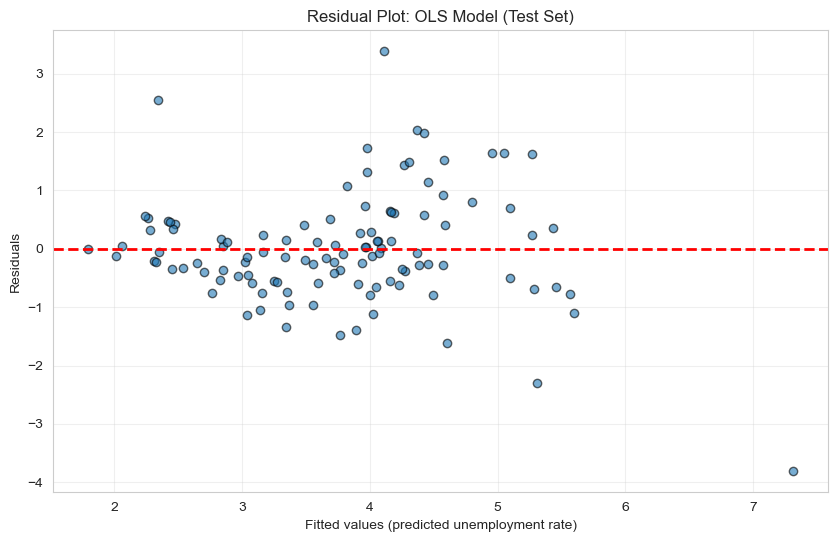

In [19]:
#| label: residual-plot

# Compute residuals for test set (OLS)
residuals_test = y_test - y_test_pred_ols
fitted_test = y_test_pred_ols

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(fitted_test, residuals_test, alpha=0.6, edgecolor='black')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Fitted values (predicted unemployment rate)')
plt.ylabel('Residuals')
plt.title('Residual Plot: OLS Model (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

### **Interpretation**

**What we want to see:**

* No obvious pattern in the residuals
* Roughly constant vertical spread across fitted values
* Residuals centred around zero

This suggests that the linear model captures the main structure of the data reasonably well.

**Common red flags (with context):**

* **Funnel shapes → heteroskedasticity**
  → The model is much more uncertain for some areas than others (e.g. high-unemployment local authorities).

* **Curvature → non-linearity**
  → The relationship between predictors and unemployment may not be well approximated by a linear form.

* **Clusters → omitted variables or group effects**
  → For example, residuals clustering by region may indicate missing regional factors or spatial dependence.

**How we interpret our actual plot in practice**

The residuals vs fitted values plot for our multivariate modelshows:

* Residuals are **roughly centred around zero**, which suggests no strong overall bias in predictions.
* However, the **spread of residuals increases as fitted unemployment rates increase**, especially above ~4–5 percentage points.
  → This is indicative of **heteroskedasticity**: the model is less reliable for areas with higher predicted unemployment.
* There are a few **large negative residuals at high fitted values**, meaning the model **overpredicts unemployment** for some high-unemployment local authorities.
* No strong curvature is visible, suggesting that a linear functional form is not grossly inappropriate, but the increasing spread indicates that **error variance is not constant**.

**Interpretation in context:**

The model performs reasonably for low-to-moderate unemployment areas but becomes increasingly uncertain and occasionally inaccurate for high-unemployment local authorities. This suggests that important dynamics affecting high-unemployment areas may not be fully captured.

---

### **Distribution of residuals**

While the residual–fitted plot focuses on structure, the distribution of residuals helps us understand **error behaviour overall**.

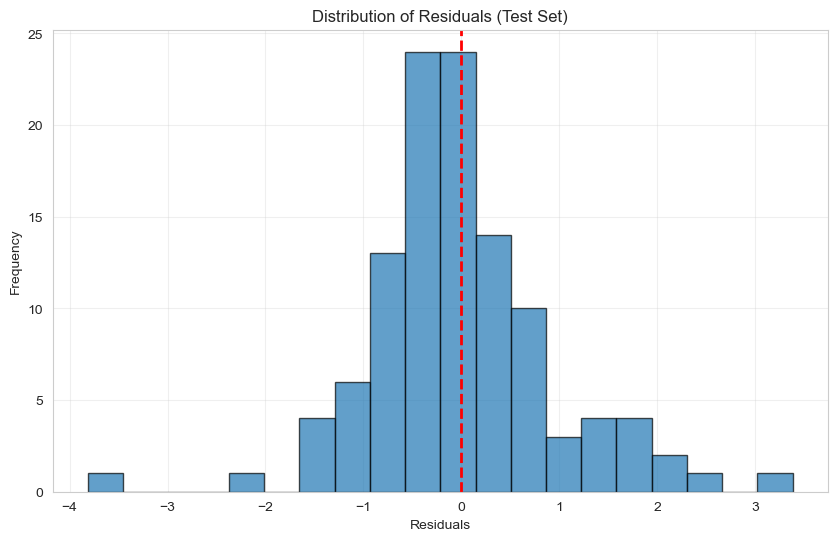


Residual statistics:
Mean: -0.0014 (should be ~0)
Std Dev: 0.9477
Skewness: 0.1736 (ideally ~0)


In [20]:
#| label: residual-distribution

plt.figure(figsize=(10, 6))
plt.hist(residuals_test, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Test Set)')
plt.grid(True, alpha=0.3)
plt.show()

print("\nResidual statistics:")
print(f"Mean: {residuals_test.mean():.4f} (should be ~0)")
print(f"Std Dev: {residuals_test.std():.4f}")
print(f"Skewness: {residuals_test.skew():.4f} (ideally ~0)")

### **Interpretation**

* **Rough symmetry around zero** is desirable
  → Errors are not systematically biased upward or downward.

* **Heavy tails** suggest:

  * outliers (e.g. atypical local authorities), or
  * skewed error processes that the model does not capture.

* **Normality of residuals** matters mainly for **statistical inference** (e.g. confidence intervals, hypothesis tests),
  not for predictive accuracy itself.

In predictive settings, mild departures from normality are common and usually acceptable.

**Interpretation of our actual residuals distribution histogram**

From the histogram:

* Residuals are **approximately centred around zero**, consistent with the mean residual being close to zero.
* The distribution shows **mild right skew** and **heavy tails**, indicating the presence of outliers.
* A small number of observations have **very large residuals** (both positive and negative), which are likely driving RMSE more than MAE.

**Interpretation in context:**

Most local authorities are predicted reasonably well, but a small number behave very differently from what the model expects. These may correspond to atypical labour markets, structural economic shocks, or omitted local factors.

---

### Residual diagnostics summary

> Together, the residual plots show that while the multivariate OLS model performs well on average, its errors are not uniform across contexts. Prediction uncertainty increases for high-unemployment local authorities, and a small number of areas exhibit unusually large errors. These patterns are invisible in aggregate metrics but are critical for understanding where and why the model fails.


::: callout-note

### 📌 Heteroskedasticity: what it signals, and how different responses address it

Heteroskedasticity indicates that the model’s prediction errors vary systematically across observations.
This creates **two distinct issues**:

* a **model adequacy problem** (the model fails to capture structure in some parts of the data), and
* an **interpretation problem** (uncertainty around coefficients is mismeasured).

The fixes below address **different aspects** of the problem. It is important to understand *which problem each fix targets*.


#### 1️⃣ Transforming the outcome (e.g. log unemployment rate)

**What this changes in the model:**
The dependent variable is transformed before fitting the model, which changes both the fitted coefficients and the scale on which errors are measured.

**When this can reduce heteroskedasticity:**
Outcome transformations are effective when:

* the outcome is strictly positive, and
* error variance increases proportionally with the level of the outcome (multiplicative errors).

In unemployment prediction, this may apply **only if** the unemployment rate distribution is strongly right-skewed and higher unemployment areas show proportionally larger variability.

**Limitations in this context:**
In local-authority unemployment data, rates are bounded and often clustered in a relatively narrow range. If heteroskedasticity is driven by structural differences across areas (e.g. urban labour markets vs post-industrial regions), a log transform may change the scale without addressing the underlying cause of unequal errors. In that case, heteroskedasticity will persist, just on a transformed scale. Heteroskedasticity here is more likely to reflect **structural differences across local authorities** (e.g. urban vs rural, industrial composition) than pure scale effects.


👉 Risk: adds complexity and complicates interpretation without solving the core problem.

**What it addresses:**

✔ Can improve model adequacy
✔ Can reduce heteroskedasticity
✘ Changes interpretation (coefficients no longer correspond to percentage-point changes)
✘ Does not solve heteroskedasticity if structural factors are at play

---

#### 2️⃣ Adding missing structure (interactions, nonlinearities, group effects)

**What this changes in the model:**
The functional form of the model is enriched, allowing relationships to differ across contexts.

Examples include:

* interactions (e.g. population density × transport access),
* nonlinear effects (e.g. diminishing returns to income),
* group-level effects (e.g. region or urban–rural indicators).

**Why this is highly relevant here:**
In area-level unemployment data, higher-unemployment local authorities often differ in **systematic, interacting ways** that are not captured by additive linear terms. When these differences are ignored, the model produces larger errors in certain regions of the feature space.

**What it addresses:**

✔ Directly targets model adequacy
✔ Often reduces heteroskedasticity by explaining why some observations are harder to predict
✔ Improves prediction and interpretability when well chosen

**Key limitation in this application:**

While highly plausible, this approach requires substantive judgement: poorly chosen interactions or nonlinear terms can overfit the training data or make the model harder to interpret. Moreover, not all relevant structure may be observable in the available covariates.

👉 Risk: improves fit locally but may still miss unobserved heterogeneity.



#### 3️⃣ Robust standard errors *(addresses interpretation, not the model)*

**What robust standard errors are:**
Robust (heteroskedasticity-consistent) standard errors are an alternative way of estimating the **uncertainty** of OLS coefficients when error variance is not constant.

They are computed **after fitting an OLS model**.

**What changes compared to standard OLS:**

* The **coefficients are identical**
* The **predictions and residuals are identical**

What changes is the **variance estimator** used to compute:

* standard errors,
* confidence intervals,
* hypothesis tests.

Standard OLS assumes constant error variance when computing standard errors; robust standard errors relax this assumption.

**What this addresses:**

✔ Fixes the **interpretation problem** under heteroskedasticity
✘ Does *not* reduce heteroskedasticity
✘ Does *not* improve MAE, RMSE, or residual patterns

**Key limitation in this application:**

Robust standard errors do nothing to improve predictions, reduce residual spread, or remove systematic patterns. If the model systematically under- or over-predicts unemployment for certain types of local authorities, those failures remain unchanged.

👉 Risk: gives a false sense that the problem has been “handled” when only inference has been corrected.

**Why it is still mentioned:**
Even when prediction is the main goal, we often interpret coefficients. Robust standard errors ensure those interpretations are not misleading when heteroskedasticity is present.


#### 4️⃣ Weighted least squares (WLS)

**What this changes in the model:**

Unlike robust standard errors, WLS **changes the estimation itself**.

Instead of minimising an unweighted sum of squared residuals (OLS), WLS minimises a **weighted** sum, giving some observations more influence than others.

**How this relates to heteroskedasticity:**

If observations with higher error variance are downweighted appropriately, WLS can:

* reduce the impact of noisy observations,
* improve efficiency,
* and sometimes reduce heteroskedasticity.

**Practical difficulty in this context:**

WLS requires a **credible model of the error variance** (or a defensible proxy). In unemployment prediction, specifying such a variance model across local authorities is often difficult: variance may differ for many overlapping reasons (economic structure, population size, data quality), making it difficult to justify a single weighting scheme. Arbitrary weights can bias results and undermine transparency.

👉 Risk: replaces one modelling assumption with another that is harder to justify.

**What it addresses:**
✔ Can affect model adequacy *if* variance is well modelled
✔ Changes coefficients and predictions
⚠ Requires strong justification


#### 5️⃣ Changing the model class

**What this changes in the model:**
The assumption of a single global linear relationship is relaxed.

Non-linear or tree-based models:

* allow relationships to vary across the feature space,
* naturally accommodate different error variances in different regions,
* often reduce heteroskedasticity without explicit variance modelling.

**Trade-offs:**
These models may improve predictive accuracy and reduce systematic residual patterns, but:

* are harder to interpret,
* make partial-effect reasoning less transparent,
* may be less suitable for policy explanation.

**Key limitation in this application:**

Although non-linear models may reduce heteroskedasticity, they do so by absorbing complexity, not by explaining it. This limits their usefulness for interpretation, policy discussion, and understanding mechanisms—especially when the goal is to reason about partial effects.

👉 Risk: better predictions at the cost of explanatory clarity.

**What it addresses:**
✔ Often improves model adequacy
✔ Can substantially reduce heteroskedasticity
✘ Reduces interpretability


### 🧠 Quick summary

> Some fixes aim to **change the model so that heteroskedasticity is reduced** (1, 2, 4, 5).
> Others accept heteroskedasticity and instead ensure **safe interpretation** of results (3).
> No single response “fixes” heteroskedasticity universally; each approach trades off predictive performance, interpretability, and transparency in different ways.
:::

---

## **1.8.3 Linear Regression Assumptions**

Linear regression relies on assumptions about **errors**, not about the predictors themselves.

Residual diagnostics are how we check these assumptions empirically.

1. **Linearity**
   The average relationship between predictors and the outcome is linear in parameters.
   → Violations show up as curvature in residual plots.

2. **Independence**
   Observations are independent of each other.
   → Often violated in spatial or temporal data (e.g. neighbouring local authorities).

3. **Homoskedasticity**
   Error variance is constant across observations.
   → Violations appear as funnel-shaped residual plots.

4. **No perfect multicollinearity**
   Predictors are not exact linear combinations of each other.
   → Affects coefficient stability rather than residual shape.

5. **Normality of errors** *(for inference, not prediction)*
   Residuals are approximately normally distributed.
   → Mainly relevant for confidence intervals and hypothesis tests.

---

### Why this matters in practice

Residual analysis helps answer a deeper question than metrics alone:

> *Is the model wrong because it is noisy, or because it is conceptually misspecified?*

This distinction is crucial when deciding whether to:

* add interactions or nonlinear terms,
* transform variables,
* move to regularised models, or
* abandon linear models altogether.

---

### Further reading

General ML perspective:

> [https://www.statlearning.com/](https://www.statlearning.com/)
> *(Chapter on Linear Regression)*

More econometrics-oriented:

> [https://www.econometrics-with-r.org](https://www.econometrics-with-r.org)


---



## 1.9. Regularization: Ridge, Lasso, Elastic Net

Many predictors in this dataset are strongly correlated. For example, urban areas tend to have higher population density, higher incomes, better transport access, and better digital infrastructure. When predictors carry overlapping information, ordinary least squares struggles to allocate explanatory power cleanly across them.

In such settings, OLS coefficients can become unstable, overly sensitive to small changes in the data, and difficult to interpret. Regularisation addresses this by explicitly constraining coefficient size, trading a small increase in bias for a reduction in variance.

:::callout-tip

### Variance Inflation Factors (VIFs): why collinearity matters

The Variance Inflation Factor (VIF) measures how much the variance of a coefficient estimate is inflated due to correlation with other predictors.

A VIF of 1 means no correlation.

Values above 5–10 indicate serious multicollinearity.

High VIFs do not bias coefficients, but they make them unstable and noisy, meaning that small changes in the data can lead to large changes in coefficient values. Regularisation reduces this instability by shrinking coefficients toward zero.

Computing VIFs might help you assess collinearity in your models and check whether regularisation could be beneficial.

**Python code to compute VIFs:**

In [21]:
# Compute VIFs on training data (standardised predictors)
X_vif = X_train_imputed.copy()

vif_df = pd.DataFrame({
    "Feature": X_vif.columns,
    "VIF": [variance_inflation_factor(X_vif.values, i)
            for i in range(X_vif.shape[1])]
}).sort_values("VIF", ascending=False)

print("Variance Inflation Factors (VIF):")
print(vif_df.to_string(index=False))


Variance Inflation Factors (VIF):
               Feature       VIF
    travel_time_bike   45.739433
     travel_time_car   43.128946
   travel_time_pt_walk 18.623557
           coverage_5g  4.301887
     gigabit_broadband  3.959244
         pct_age_16_64  3.591213
    population_density  3.583133
     median_weekly_pay  3.439135
         gdhi_per_head  3.412684
 premises_below_30mbps  3.224658
           coverage_4g  2.901920
    business_births     2.159743
    business_deaths     1.680042
    cancer_stage1_2     1.542209
high_growth_businesses  1.399316
     active_businesses  1.063781


The VIF results show severe multicollinearity among transport-related variables and moderate multicollinearity among income, density, and infrastructure measures. This means that OLS coefficients are statistically unstable and difficult to interpret, even though overall model fit is strong. Regularisation is therefore motivated not primarily to improve predictive accuracy, but to stabilise coefficient estimates in the presence of overlapping predictors.

:::

### 1.9.1 How regularisation works (intuition)

Linear regression minimises:

$$
\text{Error}
$$

Regularised regression minimises:

$$
\text{Error} + \text{Penalty}
$$

The penalty discourages large coefficients.

---

## Notation

* $y_i$: outcome for observation $i$
* $\mathbf{x}_i = (x_{i1}, \dots, x_{ip})$: predictors
* $\mathbf{\beta} = (\beta_0, \beta_1, \dots, \beta_p)$: coefficients
* $n$: number of observations
* $p$: number of predictors
* $\lambda \ge 0$: regularization strength

More formally:

**Ordinary Least Squares (OLS)**

*Objective function:*

$$
\hat{\mathbf{\beta}}^{OLS}
= \arg\min_{\mathbf{\beta}}
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
$$

*Interpretation:*

* Minimize **sum of squared residuals**
* All coefficients are chosen purely to fit the data
* No constraint on coefficient size

*Limitation:*

* High variance when:
  * Predictors are correlated
  * $p$ is large relative to $n$
  * Noise is high

Enter regularization (we **do not penalize the intercept** $\beta_0$!)

---

### 1.9.2 Ridge regression (L2 regularization)

#### Objective function

$$
\hat{\mathbf{\beta}}^{Ridge}
= \arg\min_{\mathbf{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
+
\lambda
\sum_{j=1}^{p} \beta_j^2
\right]
$$

#### Penalty term

$$
\lambda \sum_{j=1}^{p} \beta_j^2
$$

This is the **L2 norm:**

$$
\|\mathbf{\beta}\|_2^2
$$

---

#### Interpretation

* Penalizes **large coefficients**
* Shrinks coefficients **smoothly toward zero**
* **Never sets coefficients exactly to zero**

#### Effect of $\lambda$

* $\lambda = 0$ → OLS
* Large $\lambda$ → strong shrinkage → underfitting

---

#### Why Ridge works well

* Stabilizes estimates under multicollinearity
* Reduces variance
* Keeps all predictors in the model

---

### 1.9.3 Lasso Regression (L1 regularization)

#### Objective function

$$
\hat{\mathbf{\beta}}^{Lasso}
= \arg\min_{\mathbf{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
+
\lambda
\sum_{j=1}^{p} |\beta_j|
\right]
$$

#### Penalty term

$$
\lambda \sum_{j=1}^{p} |\beta_j|
$$

This is the **L1 norm:**

$$
|\mathbf{\beta}|_1
$$

---

#### Interpretation

* Penalizes absolute magnitude of coefficients
* Encourages **sparsity**
* Can set coefficients **exactly to zero**

### Key difference from Ridge

| Ridge                             | Lasso                                          |
|-----------------------------------|------------------------------------------------|
| Shrinks coefficients              | Shrinks **and selects**                        |
| Keeps all predictors              | Drops some predictors                          |
| Stable with correlated predictors | Unstable when predictors are highly correlated |


---

### 1.9.4 Elastic Net (L1 + L2 regularization)

Elastic Net combines Ridge and Lasso.

#### Objective function

$$
\hat{\mathbf{\beta}}^{EN}
= \arg\min_{\mathbf{\beta}}
\left[
\sum_{i=1}^{n}
\left(
y_i - \beta_0 - \sum_{j=1}^{p} x_{ij} \beta_j
\right)^2
+
\lambda
\left(
\alpha \sum_{j=1}^{p} |\beta_j|
+
(1-\alpha)\sum_{j=1}^{p} \beta_j^2
\right)
\right]
$$

---

#### Parameters

* $\lambda \ge 0$: overall strength of regularization
* $\alpha \in [0,1]$: balance between L1 and L2

| $\alpha$ | Model       |
|-----------|-------------|
| 0         | Ridge       |
| 1         | Lasso       |
| Between   | Elastic Net |

---

#### Interpretation

* Combines:
  * Ridge's stability
  * Lasso's variable selection
  
* Particularly useful when:
  * Many correlated predictors
  * You want sparsity **and** stability
  * You don't want to remove variables randomly (groups of variables)

---

### 1.9.5 Why scaling is required (critical point)

Regularization penalizes **coefficient magnitude**, not variable importance.

If predictors are on different scales:

* Large-scale variables → artificially small coefficients
* Small-scale variables → heavily penalized

Therefore:

> **Standardization (zero mean, unit variance) is mandatory before regularization**

Mathematically:

$$
x_{ij}^{*} = \frac{x_{ij} - \mu_j}{\sigma_j}
$$

Only then are penalties comparable across predictors.

---

### 1.9.6 Pros and cons**

| Method | Pros                    | Cons                                       |
|--------|-------------------------|-------------------------------------------|
| OLS    | Interpretable, unbiased | Unstable with collinearity                |
| Ridge  | Stable, predictive      | Harder to interpret                       |
| Lasso  | Sparse, interpretable   | Can drop correlated predictors arbitrarily|


### 1.9.7 Summary table

| Model       | Penalty            | Shrinkage | Variable selection | Best used when                    |
|-------------|--------------------|-----------|--------------------|-----------------------------------|
| OLS         | None               | ❌         | ❌                  | Few predictors, low collinearity  |
| Ridge       | $\sum \beta^2$  | ✅         | ❌                  | Multicollinearity                 |
| Lasso       | $\sum |\beta|$  | ✅         | ✅                  | Feature selection                 |
| Elastic Net | L1 + L2            | ✅         | ✅                  | Correlated predictors + selection |

---

### 1.9.10 Implementation

#### Ridge

In [22]:
#| label: model-ridge

ridge = Ridge(alpha=1.0)  # alpha is λ in sklearn
ridge.fit(X_train_imputed, y_train)

# Predictions
y_train_pred_ridge = ridge.predict(X_train_imputed)
y_test_pred_ridge = ridge.predict(X_test_imputed)

ridge_train = compute_metrics(ridge, X_train_imputed, y_train, "Ridge (Train)")
ridge_test = compute_metrics(ridge, X_test_imputed, y_test, "Ridge (Test)")

print("Ridge coefficients:")
ridge_coef_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Coefficient': ridge.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(ridge_coef_df.to_string(index=False))

Ridge coefficients:
               Feature  Coefficient
   travel_time_pt_walk    -0.640318
    population_density     0.421418
     median_weekly_pay    -0.345280
    travel_time_bike       0.324295
    business_births        0.308205
     travel_time_car       0.193666
         gdhi_per_head    -0.192265
     gigabit_broadband     0.190243
    business_deaths        0.145991
 premises_below_30mbps     0.118801
           coverage_5g    -0.098532
high_growth_businesses    -0.055115
         pct_age_16_64    -0.041300
    cancer_stage1_2       -0.035138
     active_businesses     0.027870
           coverage_4g     0.016040


Ridge regression produces coefficients that are very similar in sign and relative magnitude to OLS, but slightly smaller. This indicates that multicollinearity was inflating coefficient magnitudes rather than fundamentally distorting relationships.

**How Ridge works:**

* Shrinks all coefficients toward zero
* Keeps all variables
* Reduces variance
* Handles multicollinearity well

**When to use Ridge:**

* Many correlated predictors
* Prediction-focused analysis
* When all variables may matter a little

---

#### Lasso

In [23]:
#| label: model-lasso

lasso = Lasso(alpha=0.05, max_iter=10000)
lasso.fit(X_train_imputed, y_train)

# Predictions
y_train_pred_lasso = lasso.predict(X_train_imputed)
y_test_pred_lasso = lasso.predict(X_test_imputed)

lasso_train = compute_metrics(lasso, X_train_imputed, y_train, "Lasso (Train)")
lasso_test = compute_metrics(lasso, X_test_imputed, y_test, "Lasso (Test)")

print("Lasso coefficients:")
lasso_coef_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Coefficient': lasso.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(lasso_coef_df.to_string(index=False))

# Count zero coefficients
n_zero = (lasso.coef_ == 0).sum()
print(f"\nNumber of features set to exactly zero: {n_zero} out of {len(lasso.coef_)}")

Lasso coefficients:
               Feature  Coefficient
    population_density     0.363372
    business_births        0.312463
     median_weekly_pay    -0.273483
         gdhi_per_head    -0.186013
    business_deaths        0.135865
   travel_time_pt_walk    -0.063490
    cancer_stage1_2       -0.041451
           coverage_4g    -0.012420
high_growth_businesses    -0.008807
         pct_age_16_64     0.000000
     active_businesses     0.000000
     gigabit_broadband     0.000000
           coverage_5g    -0.000000
 premises_below_30mbps     0.000000
    travel_time_bike      -0.000000
     travel_time_car      -0.000000

Number of features set to exactly zero: 7 out of 16


Lasso sets 7 out of 16 coefficients to exactly zero, producing a much simpler model. However, several dropped variables are plausibly important (e.g. transport measures), suggesting that Lasso may be discarding variables not because they are irrelevant, but because they are correlated with others.

**How Lasso works:**

* Shrinks some coefficients to exactly zero
* Performs variable selection
* Produces sparse models

**When to use Lasso:**

* Interpretability matters
* You suspect many predictors are redundant
* Feature selection is desired

---

#### Elastic Net

In [24]:
#| label: model-elasticnet

elasticnet = ElasticNet(
    alpha=0.05,      # Overall regularization strength
    l1_ratio=0.5,    # Balance: 0.5 = half L1, half L2
    max_iter=10000,
    random_state=42
)

elasticnet.fit(X_train_imputed, y_train)

# Predictions
y_train_pred_en = elasticnet.predict(X_train_imputed)
y_test_pred_en = elasticnet.predict(X_test_imputed)

en_train = compute_metrics(elasticnet, X_train_imputed, y_train, "ElasticNet (Train)")
en_test = compute_metrics(elasticnet, X_test_imputed, y_test, "ElasticNet (Test)")

print("Elastic Net coefficients:")
en_coef_df = pd.DataFrame({
    'Feature': X_train_imputed.columns,
    'Coefficient': elasticnet.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(en_coef_df.to_string(index=False))

Elastic Net coefficients:
               Feature  Coefficient
    population_density     0.384841
    business_births        0.302594
     median_weekly_pay    -0.299923
         gdhi_per_head    -0.189380
    business_deaths        0.140209
   travel_time_pt_walk    -0.101279
    cancer_stage1_2       -0.054074
           coverage_4g    -0.037264
high_growth_businesses    -0.033179
 premises_below_30mbps     0.010849
     gigabit_broadband     0.010699
     active_businesses     0.008627
         pct_age_16_64     0.000000
           coverage_5g    -0.000000
    travel_time_bike       0.000000
     travel_time_car       0.000000


Elastic Net strikes a balance: it retains groups of related predictors while still shrinking coefficients. In this application, Elastic Net provides a good compromise between stability and interpretability.

---

### 1.9.11 Effect of regularization on model coefficients

In regularised models, coefficients should be interpreted as shrunken partial associations, not unbiased estimates of “true effects”. Shrinkage deliberately trades a small amount of bias for a substantial reduction in variance and instability. As a result, coefficient magnitudes are more conservative and more robust to multicollinearity than in OLS.

When predictors are strongly correlated, differences in coefficient size across Ridge, Lasso, and Elastic Net reflect modelling choices, not contradictions in the data.

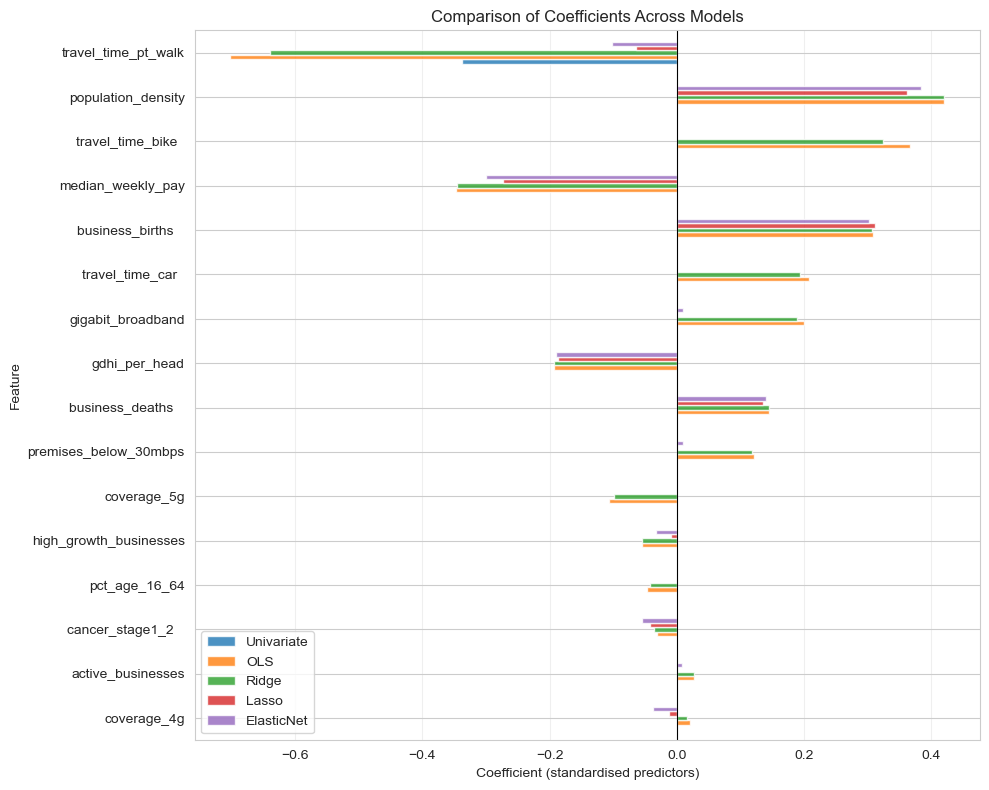


Coefficient comparison table:
               Feature  Univariate       OLS     Ridge     Lasso  ElasticNet
    population_density    0.000000  0.421308  0.421418  0.363372    0.384841
         pct_age_16_64    0.000000 -0.047078 -0.041300  0.000000    0.000000
         gdhi_per_head    0.000000 -0.193044 -0.192265 -0.186013   -0.189380
     median_weekly_pay    0.000000 -0.347284 -0.345280 -0.273483   -0.299923
     active_businesses    0.000000  0.027545  0.027870  0.000000    0.008627
    business_births       0.000000  0.308810  0.308205  0.312463    0.302594
    business_deaths       0.000000  0.144794  0.145991  0.135865    0.140209
high_growth_businesses    0.000000 -0.054778 -0.055115 -0.008807   -0.033179
    cancer_stage1_2       0.000000 -0.031563 -0.035138 -0.041451   -0.054074
     gigabit_broadband    0.000000  0.199951  0.190243  0.000000    0.010699
           coverage_4g    0.000000  0.021894  0.016040 -0.012420   -0.037264
           coverage_5g    0.000000 -0.106214 

In [25]:
#| label: compare-coefficients

coef_comparison = pd.DataFrame({
    "Feature": X_train_imputed.columns,
    "Univariate": np.concatenate([[0]*(len(X_train_imputed.columns)-1), model_uni.coef_]),  # Only GDHI
    "OLS": model_ols.coef_,
    "Ridge": ridge.coef_,
    "Lasso": lasso.coef_,
    "ElasticNet": elasticnet.coef_
})

# Reorder features by absolute OLS coefficient (or Ridge)
order = coef_comparison.set_index("Feature")["OLS"].abs().sort_values().index
coef_plot_df = coef_comparison.set_index("Feature").loc[order]

fig, ax = plt.subplots(figsize=(10, 8))

coef_plot_df.plot(
    kind="barh",
    ax=ax,
    alpha=0.8
)

ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Coefficient (standardised predictors)")
ax.set_title("Comparison of Coefficients Across Models")
ax.grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.show()

print("\nCoefficient comparison table:")
print(coef_comparison.to_string(index=False))

**Interpreting the coefficient comparison plot:**

The plot compares estimated coefficients from five linear models: a univariate regression, a multivariate OLS model, and three regularised models (Ridge, Lasso, Elastic Net). All predictors were **standardised before modelling**, so each coefficient represents the expected change in the unemployment rate (in percentage points) associated with a **one–standard-deviation increase in the predictor**, holding other variables constant. This makes coefficients directly comparable **within and across models**.

Several patterns stand out. First, the **OLS model produces relatively large coefficients**, especially for variables related to income, education, and urban density. This reflects the fact that many predictors in this dataset are strongly correlated with each other (for example, urban areas tend to have higher income, better education, and more services). In such settings, OLS has difficulty allocating explanatory power across correlated predictors, leading to **inflated and unstable coefficients**. Large coefficients here should not be interpreted as strong causal effects; rather, they often reflect shared information among groups of variables.

Regularisation changes this picture substantially. **Ridge regression shrinks coefficients toward zero while keeping all predictors**, resulting in smaller, more stable estimates that distribute influence across correlated variables. **Lasso regression**, by contrast, forces some coefficients to exactly zero, effectively selecting a subset of predictors and discarding others. This can aid interpretability, but in the presence of multicollinearity it may arbitrarily select one variable from a correlated group and exclude the rest. **Elastic Net provides a compromise**, combining shrinkage with partial variable selection and tending to keep groups of related predictors together. In this dataset, Elastic Net produces coefficients that are smaller and more stable than OLS, but less aggressive than Lasso.

Taken together, the plot illustrates a central lesson of applied modelling: **coefficients are not fixed properties of the data**. Their magnitude and even their sign depend on modelling choices, especially when predictors are correlated. Regularisation does not merely improve prediction; it fundamentally alters how we should interpret coefficients. In practice, coefficient plots like this are valuable diagnostic tools, helping us understand which relationships are robust across modelling assumptions and which are sensitive to multicollinearity and model complexity.

---

### 1.9.12 Final Metrics Comparison

In [26]:
#| label: final-comparison

# Combine all metrics
final_metrics = pd.DataFrame([
    uni_train, uni_test,
    ols_train, ols_test,
    ridge_train, ridge_test,
    lasso_train, lasso_test,
    en_train, en_test
])

# Add train/test indicator
final_metrics['Set'] = ['Train', 'Test'] * 5

# Reorder columns
final_metrics = final_metrics[['Model', 'Set', 'MAE', 'RMSE', 'R²']]

print("\n" + "="*70)
print("FINAL MODEL COMPARISON")
print("="*70)
print(final_metrics.to_string(index=False))
print("="*70)


FINAL MODEL COMPARISON
             Model   Set      MAE     RMSE       R²
Univariate (Train) Train 0.840175 1.063119 0.091841
 Univariate (Test)  Test 0.970435 1.240795 0.075827
       OLS (Train) Train 0.558215 0.731352 0.570216
        OLS (Test)  Test 0.667651 0.943478 0.465661
     Ridge (Train) Train 0.558405 0.731512 0.570027
      Ridge (Test)  Test 0.666091 0.943544 0.465587
     Lasso (Train) Train 0.582262 0.762241 0.533145
      Lasso (Test)  Test 0.674327 0.979552 0.424019
ElasticNet (Train) Train 0.575435 0.753574 0.543701
 ElasticNet (Test)  Test 0.663539 0.960254 0.446490


We can visualise the metrics in a plot:

In [27]:
#| label: plot-final-comparison

plot_df = final_metrics.copy()

# Create a base model name without "(Train)/(Test)"
plot_df["BaseModel"] = plot_df["Model"].str.replace(r"\s*\(Train\)|\s*\(Test\)", "", regex=True)

# Force the order we want
model_order = ["Univariate", "OLS", "Ridge", "Lasso", "ElasticNet"]
plot_df["BaseModel"] = pd.Categorical(plot_df["BaseModel"], categories=model_order, ordered=True)

fig = px.bar(
    plot_df,
    x="BaseModel",
    y="RMSE",                 # swap to "MAE" or "R²" if needed
    color="Set",              # Train vs Test bars next to each other
    barmode="group",
    category_orders={"BaseModel": model_order, "Set": ["Train", "Test"]},
    title="Training vs Test RMSE Across Models",
    labels={"RMSE": "RMSE (percentage points of unemployment)", "BaseModel": "Model"},
    hover_data={"MAE": True, "R²": True, "BaseModel": False}
)

fig.update_layout(
    template="simple_white",
    hovermode="x unified"
)

fig.show()


**Key observations:**

1. **Train vs Test gap**: Look for models with similar train and test performance
2. **Regularization effect**: Ridge/Lasso/ElasticNet typically have slightly worse train performance but better test performance
3. **Model selection**: Choose based on:
4. 
   - Prediction accuracy (test RMSE)
   - Interpretability (number of non-zero coefficients)
   - Stability (train-test gap)

In this case:

- High VIFs explain why OLS coefficients are unstable; regularisation stabilises them; metrics confirm that this stabilisation does not come at a meaningful cost in predictive accuracy.
- the fact that Ridge, Lasso, and Elastic Net have very similar test-set RMSE to OLS indicates that most predictive signal is already captured by the linear structure. The benefit of regularisation here lies less in raw accuracy gains and more in stability, robustness, and interpretability under multicollinearity.

---

### 1.9.13 Key takeaway**

> Regularisation is not a technical fix — it encodes modelling priorities.

* OLS prioritises unbiased estimation
* Ridge prioritises prediction
* Lasso prioritises simplicity and interpretability

**Which model should I choose?**

- If prediction is the only goal → Ridge or Elastic Net

- If interpretability and sparsity matter → Lasso (with caution under collinearity)

- If explanation and coefficient interpretation matter → OLS, but interpret cautiously

---

# Part 2: From Regression to Classification 🎯

## 2.1. Why Classification?

So far we've predicted **unemployment rate** (continuous). But what if we want to predict **categories**?

**Examples:**

* High vs. Low unemployment (binary)
* High vs. Medium vs. Low (multi-class)
* Will a local authority exceed national average? (binary)

**Key difference:**

* **Regression**: Predicts quantities (how much?)
* **Classification**: Predicts categories (which class?)

---

## 2.2 Creating a Binary Outcome

Let's create a simple binary classification problem from our data:

In [28]:
#| label: create-binary

# Create binary outcome: Above or below median unemployment
median_unemp = ons_data_cleaned['modelled_unemployment_rate'].median()

ons_data_cleaned['high_unemployment'] = (
    ons_data_cleaned['modelled_unemployment_rate'] > median_unemp
).astype(int)

print(f"Median unemployment rate: {median_unemp:.2f}%")
print(f"\nClass distribution:")
print(ons_data_cleaned['high_unemployment'].value_counts())
print(f"\nBalanced? {ons_data_cleaned['high_unemployment'].value_counts()[0] / len(ons_data_cleaned):.2%} in class 0")

Median unemployment rate: 3.60%

Class distribution:
high_unemployment
0    192
1    179
Name: count, dtype: int64

Balanced? 51.75% in class 0


A visualisation of the class distribution:

In [29]:
#| label: plot-binary-distribution

counts = ons_data_cleaned["high_unemployment"].value_counts().sort_index()
df_imb = pd.DataFrame({
    "Class": ["0 (≤ median unemployment)", "1 (> median unemployment)"],
    "Count": counts.values,
})
df_imb["Percent"] = 100 * df_imb["Count"] / df_imb["Count"].sum()

fig = px.bar(
    df_imb,
    x="Class",
    y="Count",
    title="Class Distribution of Binary Unemployment Outcome",
    hover_data={"Count": True, "Percent": ":.2f"},
    labels={"Count": "Number of local authorities"}
)

fig.update_layout(template="simple_white")
fig.show()

**Why this split?**

- Defines a relative notion of “high unemployment”, based on the distribution of observed rates rather than an arbitrary threshold

- Produces a relatively balanced classification problem (≈51.75% below-median vs ≈48.25% above-median), avoiding extreme class imbalance

- Keeps the task interpretable: *Which local authorities have higher unemployment than most others?*

- Mimics policy-style ranking questions, where interest often lies in identifying comparatively worse-off areas, not in absolute cutoffs

---

## 2.3 Why Linear Regression Fails for Classification

Let's try using linear regression to predict our binary outcome:

Plotting 370 observations
Class 0: 191 | Class 1: 179
GDHI range: £13,536 – £88,770


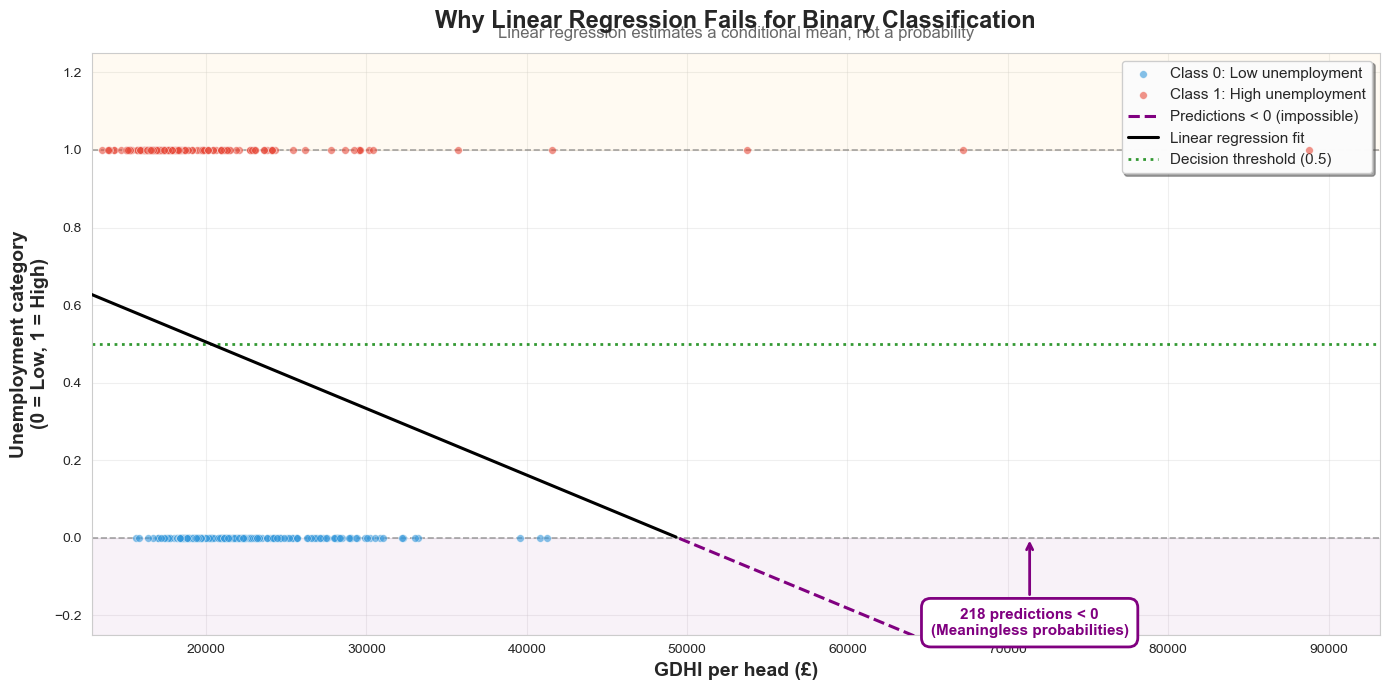

In [30]:
#| label: linear-regression-classification-no-jitter

# ------------------------------------------------------------
# Style
# ------------------------------------------------------------
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 7)

# ------------------------------------------------------------
# STEP 1: Identify rows actually used in modelling
# ------------------------------------------------------------
used_idx = X_train.index.union(X_test.index)

# ------------------------------------------------------------
# STEP 2: Pull RAW GDHI (£) + observed binary outcome
# ------------------------------------------------------------
plot_df = pd.DataFrame({
    "gdhi_raw": ons_data_cleaned.loc[used_idx, "gdhi_per_head"],
    "y": ons_data_cleaned.loc[used_idx, "high_unemployment"]
}).dropna()

X_all = plot_df["gdhi_raw"].values
y_all = plot_df["y"].astype(int).values

print(f"Plotting {len(plot_df)} observations")
print(f"Class 0: {(y_all==0).sum()} | Class 1: {(y_all==1).sum()}")
print(f"GDHI range: £{X_all.min():,.0f} – £{X_all.max():,.0f}")

# ------------------------------------------------------------
# STEP 3: Fit linear regression to binary outcome (deliberately wrong)
# ------------------------------------------------------------
lin_reg = LinearRegression()
lin_reg.fit(X_all.reshape(-1, 1), y_all)

# Prediction grid on RAW GDHI scale
x_grid = np.linspace(X_all.min() * 0.95, X_all.max() * 1.05, 400)
y_pred = lin_reg.predict(x_grid.reshape(-1, 1))

below_mask = y_pred < 0
valid_mask = (y_pred >= 0) & (y_pred <= 1)
above_mask = y_pred > 1

# ------------------------------------------------------------
# STEP 4: Plot
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(14, 7))

# Background regions (impossible probability zones)
ax.fill_between(x_grid, -0.25, 0, color="purple", alpha=0.05, zorder=1)
ax.fill_between(x_grid, 1, 1.25, color="orange", alpha=0.05, zorder=1)

# Scatter points (NO JITTER)
mask_0 = y_all == 0
mask_1 = y_all == 1

ax.scatter(
    X_all[mask_0], y_all[mask_0],
    c="#3498db", s=30, alpha=0.6,
    edgecolors="white", linewidth=0.4,
    label="Class 0: Low unemployment", zorder=6
)

ax.scatter(
    X_all[mask_1], y_all[mask_1],
    c="#e74c3c", s=30, alpha=0.6,
    edgecolors="white", linewidth=0.4,
    label="Class 1: High unemployment", zorder=6
)

# Linear regression line (segmented)
if below_mask.any():
    ax.plot(
        x_grid[below_mask], y_pred[below_mask],
        color="purple", linestyle="--", linewidth=2.2,
        label="Predictions < 0 (impossible)", zorder=5
    )

if valid_mask.any():
    ax.plot(
        x_grid[valid_mask], y_pred[valid_mask],
        color="black", linewidth=2.2,
        label="Linear regression fit", zorder=5
    )

if above_mask.any():
    ax.plot(
        x_grid[above_mask], y_pred[above_mask],
        color="orange", linestyle="--", linewidth=2.2,
        label="Predictions > 1 (impossible)", zorder=5
    )

# Reference lines
ax.axhline(0, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(1, color="gray", linestyle="--", linewidth=1.2, alpha=0.7)
ax.axhline(
    0.5, color="green", linestyle=":", linewidth=2,
    alpha=0.8, label="Decision threshold (0.5)"
)

# ------------------------------------------------------------
# STEP 5: Annotations
# ------------------------------------------------------------
n_below = below_mask.sum()
n_above = above_mask.sum()

if n_above > 0:
    ax.annotate(
        f"{n_above} predictions > 1\n(Meaningless probabilities)",
        xy=(x_grid[above_mask].mean(), 1),
        xytext=(x_grid[above_mask].mean(), 1.18),
        fontsize=11, fontweight="bold", color="orange",
        ha="center", va="bottom",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white",
                  edgecolor="orange", linewidth=2),
        arrowprops=dict(arrowstyle="->", color="orange", lw=2)
    )

if n_below > 0:
    ax.annotate(
        f"{n_below} predictions < 0\n(Meaningless probabilities)",
        xy=(x_grid[below_mask].mean(), 0),
        xytext=(x_grid[below_mask].mean(), -0.18),
        fontsize=11, fontweight="bold", color="purple",
        ha="center", va="top",
        bbox=dict(boxstyle="round,pad=0.6", facecolor="white",
                  edgecolor="purple", linewidth=2),
        arrowprops=dict(arrowstyle="->", color="purple", lw=2)
    )

# ------------------------------------------------------------
# STEP 6: Labels and layout
# ------------------------------------------------------------
ax.set_xlabel("GDHI per head (£)", fontsize=14, fontweight="bold")
ax.set_ylabel("Unemployment category\n(0 = Low, 1 = High)", fontsize=14, fontweight="bold")

ax.set_title(
    "Why Linear Regression Fails for Binary Classification",
    fontsize=17, fontweight="bold", pad=18
)

ax.text(
    0.5, 1.02,
    "Linear regression estimates a conditional mean, not a probability",
    transform=ax.transAxes,
    ha="center", va="bottom",
    fontsize=12, color="dimgray"
)

ax.set_ylim(-0.25, 1.25)
ax.set_xlim(x_grid.min(), x_grid.max())

ax.legend(
    loc="upper right", fontsize=11,
    framealpha=0.97, fancybox=True, shadow=True
)

ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


**Interpretation**

This plot illustrates why **linear regression is fundamentally unsuitable for binary classification problems**.

The observed outcome takes only two values (0 = low unemployment, 1 = high unemployment), but linear regression fits a **straight line to the conditional mean** of the outcome. As a result, the model produces predictions that **fall below 0 and above 1**, which cannot be interpreted as probabilities. Negative probabilities and probabilities greater than 1 are **nonsensical**.

Even within the $[0,1]$ range, the fitted line does not represent the probability of high unemployment in a meaningful way. The decision threshold at 0.5 is arbitrary, and small changes in the predictor can lead to unstable classification decisions. This behaviour reflects a **model–task mismatch**, not poor tuning or lack of data.

The key lesson is that **classification requires models that produce valid probabilities by construction**. Linear regression estimates a conditional mean, whereas classification models (such as logistic regression) are designed to map predictors to probabilities constrained to the $[0,1]$ interval.


**We need a better approach** → Logistic Regression

---

## 2.4 Logistic Regression

### 2.4.1 How logistic regression works (intuition)

Logistic regression starts in exactly the **same place as linear regression**: it forms a linear combination of the predictors,

$$
z = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

This quantity $z$ can take **any real value**, positive or negative.
On its own, $z$ is **not a probability**.

Instead of treating $z$ as the final prediction (as linear regression does), logistic regression applies the **sigmoid function**:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

This transformation has three crucial effects:

1. **Constrains predictions to $[0,1]$**
   No matter how large or small $z$ is, $\sigma(z)$ always lies between 0 and 1.
   This makes the output interpretable as a **probability**.

2. **Imposes a nonlinear relationship**
   Changes in predictors have **small effects** when probabilities are near 0 or 1, and **larger effects** near the middle (around 0.5).
   This reflects the idea that probabilities saturate rather than increase linearly.

3. **Creates a natural decision rule**
   A threshold (commonly 0.5) converts probabilities into class labels:
   $$
   \hat{y} =
   \begin{cases}
   1 & \text{if } P(y=1 \mid x) \ge 0.5 \
   0 & \text{otherwise}
   \end{cases}
   $$

The sigmoid function plays the role of a link function: it links an unbounded linear score $z$ to a valid probability.

The plot below shows how:

- very negative values of $z$ map to probabilities close to 0,
- very positive values map to probabilities close to 1,
- and values near $z=0$ correspond to the region of greatest uncertainty, around $P(y=1)=0.5$.

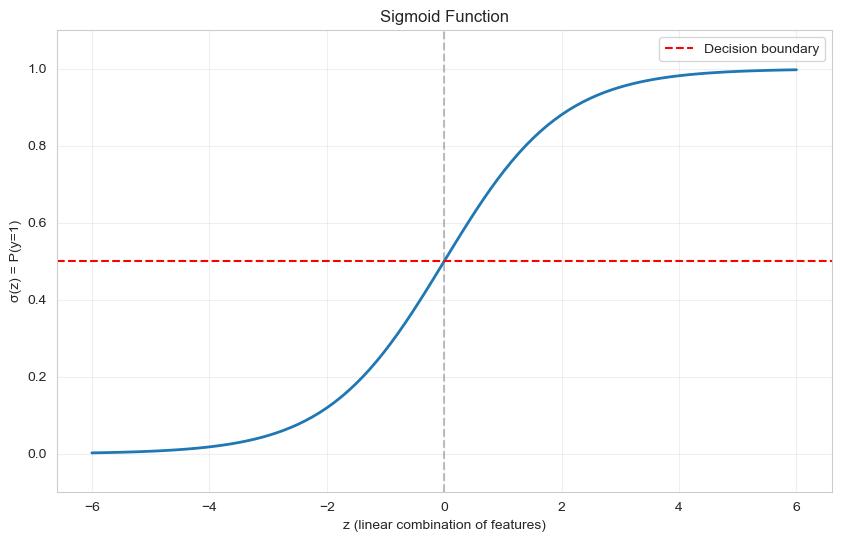

In [31]:
#| label: sigmoid-plot

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.linspace(-6, 6, 100)
plt.figure(figsize=(10, 6))
plt.plot(z, sigmoid(z), linewidth=2)
plt.axhline(y=0.5, color='red', linestyle='--', label='Decision boundary')
plt.axvline(x=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('z (linear combination of features)')
plt.ylabel('σ(z) = P(y=1)')
plt.title('Sigmoid Function')
plt.grid(True, alpha=0.3)
plt.legend()
plt.ylim(-0.1, 1.1)
plt.show()

**Key properties:**

* Output always between 0 and 1
* Interpretable as **probability** of class 1
* S-shaped curve
* Symmetric around 0.5


This S-shaped curve explains why logistic regression is nonlinear in probabilities but linear in predictors.

Each predictor shifts $z$ linearly, but its effect on the predicted probability depends on where on the curve the observation lies.

---

### 2.4.2 What logistic regression is really estimating

Logistic regression does **not** model the outcome directly.
Instead, it models the **log-odds** of the positive class:

$$
\log\left(\frac{P(y=1)}{1 - P(y=1)}\right) = \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

This means:

* Predictors shift the **odds**, not the outcome itself
* Coefficients describe **multiplicative changes in odds**
* Probabilities emerge only after applying the sigmoid transformation

---

### 2.4.3 Why this fixes the problem we saw earlier

Compared to linear regression:

| Linear regression           | Logistic regression        |
| --------------------------- | -------------------------- |
| Predicts means              | Predicts probabilities     |
| Outputs $(-\infty, \infty)$ | Outputs $[0,1]$ only       |
| Arbitrary threshold         | Probability-based decision |
| Can give impossible values  | Always valid probabilities |

---

### 2.4.4 Key takeaway

> Logistic regression keeps the familiar linear structure of regression, but wraps it in a nonlinear transformation that makes predictions probabilistic, bounded, and meaningful for classification.

---

### 2.4.5 Fitting Logistic Regression

In [34]:
#| label: fit-logistic

log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train_logistic, y_train_class)

# Get probability predictions
y_prob_train = log_reg.predict_proba(X_train_logistic)[:, 1]
y_prob_test = log_reg.predict_proba(X_test_logistic)[:, 1]

# Get class predictions (threshold = 0.5)
y_pred_train = log_reg.predict(X_train_logistic)
y_pred_test = log_reg.predict(X_test_logistic)

print("Logistic regression coefficients:")
log_coef_df = pd.DataFrame({
    'Feature': X_train_logistic.columns,
    'Coefficient': log_reg.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(log_coef_df.to_string(index=False))

NameError: name 'X_train_logistic' is not defined

---

### 2.4.6 Interpreting Logistic Regression Coefficients

Logistic regression coefficients do **not** describe changes in the outcome itself.
Instead, they describe how predictors affect the **odds** of being in the positive class.

#### From probabilities to odds (one step at a time)

For a binary outcome:

$$
\text{Odds} = \frac{P(y=1)}{1 - P(y=1)}
$$

* If $P(y=1) = 0.5$, the odds are $1$ (equally likely).
* If $P(y=1) = 0.75$, the odds are $3$ (three times more likely than not).
* If $P(y=1) = 0.25$, the odds are $1/3$.

Logistic regression models the **logarithm of these odds**:

$$
\log\left(\frac{P(y=1)}{1 - P(y=1)}\right)
= \beta_0 + \beta_1 x_1 + \dots + \beta_p x_p
$$

This keeps the model linear in the predictors while ensuring valid probabilities.

---

#### How to interpret a coefficient

Each coefficient $\beta_j$ represents the change in **log-odds** associated with a **one–standard deviation increase** in predictor $x_j$ (since predictors were standardised).

To make this interpretable:

1. Exponentiate the coefficient:
   $$
   e^{\beta_j} = \text{odds ratio}
   $$
2. Interpret the odds ratio:

   * Odds ratio **greater than 1** → odds of high unemployment increase
   * Odds ratio **less than 1** → odds of high unemployment decrease

In [ ]:
#| label: odds-ratios

log_coef_df['Odds Ratio'] = np.exp(log_coef_df['Coefficient'])
log_coef_df['Interpretation'] = log_coef_df['Odds Ratio'].apply(
    lambda x: f"{'Increases' if x > 1 else 'Decreases'} odds by {abs((x-1)*100):.1f}%"
)

print("\nOdds ratios interpretation:")
print(log_coef_df.to_string(index=False))

---

### Example interpretation (GDHI per head)

Suppose the coefficient for **GDHI per head** is $-0.47$.

* The odds ratio is:
  $$
  e^{-0.47} \approx 0.63
  $$

This means:

> A one–standard deviation increase in income (if features were standardised) is associated with a **37% decrease in the odds** of high unemployment.

Importantly, this **does not** mean that the probability of high unemployment falls by 37 percentage points.
Changes in odds translate into **different probability changes depending on the starting level of risk**.

This distinction is crucial: logistic regression models **relative risk**, not absolute probability differences.

---

### 2.4.7 Interpreting Probability Predictions

Logistic regression produces **predicted probabilities**, which allow us to assess both **classification** and **uncertainty**.

In [ ]:
#| label: probability-histogram

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(y_prob_test[y_test_class == 0], bins=20, alpha=0.7,
         label='Class 0 (Low unemp)', edgecolor='black')
plt.hist(y_prob_test[y_test_class == 1], bins=20, alpha=0.7,
         label='Class 1 (High unemp)', edgecolor='black')
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2,
            label='Decision boundary')
plt.xlabel('Predicted Probability of High Unemployment')
plt.ylabel('Frequency')
plt.title('Distribution of Predicted Probabilities')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(y_prob_test, y_test_class, alpha=0.3)
plt.axvline(x=0.5, color='red', linestyle='--', linewidth=2)
plt.yticks([0, 1], ['Low unemployment (0)', 'High unemployment (1)'])
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Class')
plt.title('Predicted Probability vs Actual Class')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

### How to read these plots

**Left panel (distributions):**

* Areas with **low unemployment** should have predicted probabilities closer to 0.
* Areas with **high unemployment** should have predicted probabilities closer to 1.
* Overlap between the two distributions is expected in social data and reflects genuine uncertainty.

**Right panel (predicted probability vs actual class):**

- Each point is one observation.
- The vertical position shows the true class (0 or 1).
- The horizontal position shows the model’s confidence in high unemployment.

This plot shows how confidently the model classifies each observation:

- Points far to the left (near 0) or right (near 1) represent confident predictions.
- Points near 0.5 represent ambiguous cases, where the model is unsure.
- The vertical line at 0.5 indicates the classification threshold, separating predictions that would be labelled as low or high unemployment.
This plot shows how confident the model is for each observation, but it does not distinguish between correct and incorrect classifications.

Importantly, this is not a regression fit plot.
There is no line to match because classification models estimate probabilities, not outcomes.

The right-hand panel does not show whether probabilities are numerically accurate; it shows how confident the model is for individual observations. Assessing whether predicted probabilities are well calibrated requires additional tools (introduced later).

---

### Key takeaway

> Logistic regression separates **probability estimation** from **classification decisions**.
> This makes it far more informative than models that only output class labels.



---

## 2.5 Evaluating Classification Models

Now that we know how to fit one type of classification model (logistic regression), how exactly do we evaluate its performance?


Unlike regression, classification models do **not** produce a single, self-evident notion of “error”.
Instead, evaluation depends on **how predicted probabilities are converted into class labels**, and on **what kinds of mistakes we care about most**.

We therefore proceed in three steps:

1. Choose a **decision threshold**
2. Examine the **confusion matrix**
3. Use **classification metrics**, each of which emphasises different aspects of performance

---

### 2.5.1 From probabilities to class labels: the decision threshold

Logistic regression outputs **probabilities**, not categories:

$$
P(y = 1 \mid x)
$$

To turn these probabilities into predicted classes, we must choose a **decision threshold** (t).

$$
\hat{y} =
\begin{cases}
1 & \text{if } P(y=1 \mid x) \ge t \
0 & \text{if } P(y=1 \mid x) < t
\end{cases}
$$

We tend to use the **standard threshold** ($t = 0.5$), meaning that if the predicted probability is 0.5 or higher, we classify the observation as belonging to the positive class (high unemployment).

#### Why the threshold is not innocuous

The threshold is **not a technical detail** — it encodes a *decision rule*.

Consider two areas with predicted probabilities:

* Area A: $P(\text{high unemp}) = 0.49$
* Area B: $P(\text{high unemp}) = 0.51$

With a 0.5 threshold:

* Area A → classified as *low*
* Area B → classified as *high*

Despite being nearly identical in probability, they receive **opposite labels**.

This illustrates two key points:

1. Classification decisions are **discrete**, but probabilities are **continuous**
2. Evaluation metrics depend critically on where we draw the threshold

Different thresholds produce **different confusion matrices**, even if the underlying probabilities are unchanged.

---

### 2.5.2 Confusion Matrix

Once a threshold has been chosen, predicted probabilities are converted into class labels.
The **confusion matrix** summarises how those predictions compare to the true outcomes.

In [ ]:
cm = confusion_matrix(y_test_class, y_pred_test)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', square=True, cbar=False,
            xticklabels=['Predicted Low', 'Predicted High'],
            yticklabels=['Actual Low', 'Actual High'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix: Test Set')
plt.show()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {cm[0,0]}")
print(f"False Positives (FP): {cm[0,1]}")
print(f"False Negatives (FN): {cm[1,0]}")
print(f"True Positives (TP): {cm[1,1]}")

|                 | Predicted Low | Predicted High |
| --------------- | ------------- | -------------- |
| **Actual Low**  | TN            | FP             |
| **Actual High** | FN            | TP             |

### Interpreting the four cells (with context)

Let “high unemployment” be the **positive class**.

* **True Negative (TN)**
  Low-unemployment area correctly identified as low
  → No intervention, correctly withheld

* **False Positive (FP)** *(Type I error)*
  Low-unemployment area incorrectly flagged as high
  → Resources potentially misallocated

* **False Negative (FN)** *(Type II error)*
  High-unemployment area missed by the model
  → Area receives no support despite need

* **True Positive (TP)**
  High-unemployment area correctly identified
  → Targeted intervention succeeds

#### Why FP and FN are not symmetric

False positives and false negatives usually have **very different consequences**.

In labour-market policy:

* FN errors are often **more serious** (missed need)
* FP errors may be **less costly** (extra screening)

This asymmetry is precisely why **accuracy alone is not enough**.

---

### 2.5.3 Classification Metrics

All classification metrics are functions of the confusion matrix, but they emphasise **different types of correctness**.

Here is what these metrics mean, and when to use them:

---

### 2.5.4 Accuracy — and why it is often misleading

$$
\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}
$$

**What accuracy measures:**
The proportion of all predictions that are correct.

#### Why accuracy can be dangerously misleading

Suppose:

* 95% of areas have low unemployment
* 5% have high unemployment

A model that **always predicts “low”** achieves:

* Accuracy = 95%
* Recall (high unemployment) = 0%

This model:

* Looks excellent by accuracy
* Completely fails at its substantive task

> **Accuracy should never be used at all when classes are imbalanced.**

Accuracy hides failure because it is dominated by the majority class.

---

### 2.5.5 Balanced accuracy

Balanced accuracy corrects this problem by treating both classes equally:

$$
\text{Balanced Accuracy}
========================

\frac{1}{2}
\left(
\frac{TP}{TP + FN}
+
\frac{TN}{TN + FP}
\right)
$$

**Interpretation:**
Average of:

* Recall for the positive class
* Recall for the negative class

Balanced accuracy answers:

> “How well does the model perform on *each class*, regardless of how common it is?”

This is often a **better default** than accuracy in classification problems.

---

### 2.5.6 Precision

$$
\text{Precision} = \frac{TP}{TP + FP}
$$

**Interpretation:**
Of all areas the model *flags as high unemployment*, how many truly are?

Precision answers:

> “When the model raises the alarm, can we trust it?”

Precision matters when:

* False positives are costly
* You want to avoid unnecessary interventions

---

### 2.5.7 Recall (Sensitivity)

$$
\text{Recall} = \frac{TP}{TP + FN}
$$

**Interpretation:**
Of all areas that truly have high unemployment, how many did the model detect?

Recall answers:

> “How many cases of need did we catch?”

Recall matters when:

* Missing true cases is costly
* The goal is coverage rather than selectivity

---

### 2.5.8 F1 score

$$
\text{F1} =
2 \cdot
\frac{\text{Precision} \cdot \text{Recall}}
{\text{Precision} + \text{Recall}}
$$

The F1 score is:

* High only if **both** precision and recall are high
* Useful when classes are imbalanced
* A single-number summary of the FP/FN trade-off

---

### 2.5.9 Calculating model metrics and interpreting the results

In [ ]:
# Compute metrics
acc = accuracy_score(y_test_class, y_pred_test)
prec = precision_score(y_test_class, y_pred_test)
rec = recall_score(y_test_class, y_pred_test)
f1 = f1_score(y_test_class, y_pred_test)

print("Classification Metrics (Test Set):")
print(f"Accuracy:  {acc:.3f}")
print(f"Precision: {prec:.3f}")
print(f"Recall:    {rec:.3f}")
print(f"F1 Score:  {f1:.3f}")

print("\n" + classification_report(y_test_class, y_pred_test))

**Test-set results:**

* Accuracy = **0.848**
* Precision = **0.800**
* Recall = **0.906**
* F1 = **0.850**

#### What this means in context

* The classes are relatively balanced (≈52% class 0, 48% class 1),
  so accuracy is **acceptable here**, though still not sufficient alone.
* High recall indicates the model rarely misses high-unemployment areas.
* Slightly lower precision indicates some false alarms.
* F1 confirms a strong overall balance.

In policy terms, this model prioritises **coverage of need** over perfect selectivity — a defensible choice in many real-world settings.

---

### 2.5.10 Training vs test metrics (still essential)

As with regression:

* Training metrics reflect **fit**
* Test metrics reflect **generalisation**

Large gaps between training and test performance indicate overfitting, regardless of which metric is used.

---

### 2.5.11 Key takeaway

> Classification evaluation is inseparable from decision thresholds and error trade-offs.

* Logistic regression estimates probabilities
* Thresholds turn probabilities into decisions
* Different metrics reward different behaviours
* Accuracy alone is rarely sufficient
* Balanced accuracy, precision, recall, and F1 provide a more honest picture

We'll see a few more evaluation tools later, but these form the essential foundation for understanding classification model performance.

---

## 2.6 The Perfect Separation Problem ⚠️

Perfect separation is one of the most important *failure modes* in classification modelling.
It is subtle, easy to miss, and often produces models that appear **too good to be true**.

---

### 2.6.1 What is Perfect Separation?

**Perfect separation** occurs when the predictor variables allow the classes to be **completely separated**, with no overlap.

Formally, this means there exists some combination of predictors such that:

* all observations with $y = 1$ lie on one side of a boundary,
* all observations with $y = 0$ lie on the other,
* and **no classification errors occur on the training data**.

This is a property of the **data**, not of a specific algorithm.

---

### 2.6.2 Why perfect separation is a modelling problem (intuition)

At first glance, perfect separation sounds ideal:

* ✔ 100% training accuracy
* ✔ Zero misclassifications
* ✔ “Very confident” predictions

However, in probabilistic modelling, this is a **red flag**.

Classification models are designed to estimate **uncertainty**.
Perfect separation forces the model to claim **absolute certainty**:

* $P(y=1 \mid x) = 1$ for some observations
* $P(y=1 \mid x) = 0$ for others

In real social and economic systems, such certainty is almost never defensible.

---

### 2.6.3 Maximum Likelihood Estimation (what’s going wrong under the hood)

Logistic regression is estimated using **Maximum Likelihood Estimation (MLE)**.

#### What MLE does (in plain terms)

MLE chooses model parameters that make the **observed outcomes as likely as possible**, given the model.

For logistic regression, this means:

* Each observation contributes a likelihood based on its predicted probability
* Correct predictions with high confidence increase the likelihood
* Incorrect predictions or low confidence reduce it

The optimiser searches for coefficients that **maximise the total likelihood** across all observations.

---

#### Why MLE breaks under perfect separation

Under perfect separation:

* The model can always increase the likelihood by making the separating coefficient **larger**
* Larger coefficients push probabilities closer to exactly 0 or 1
* There is **no finite coefficient value** at which the likelihood is maximised

As a result:

* The likelihood keeps increasing as $|\beta| \to \infty$
* The optimisation problem has **no finite solution**
* Coefficients diverge numerically
* Software reports convergence problems or extreme estimates

This is not a software issue — it is a **mathematical property of MLE under separation**.

---

### 2.6.4 Perfect separation is not unique to logistic regression

Although we first encounter perfect separation in logistic regression, it is **not specific to it**.

The same issue arises in:

* Probit models
* Complementary log–log models
* Linear probability models (in a different guise)
* More generally: **any model that tries to infer probabilities from separable data**

The common feature is **attempting probabilistic inference when the data imply deterministic rules**.

Logistic regression simply makes the problem visible early because:

* coefficients have a clear probabilistic interpretation,
* divergence shows up as numerical instability.

---

### 2.6.5 Demonstrating Perfect Separation

Let's artificially create perfect separation to see the proble:

In [ ]:
#| label: perfect-separation-demo 
# Create a nearly perfect predictor 
# # (In reality, this might be "previous year's unemployment category") 

np.random.seed(42) 
X_with_perfect = X_train_class_final.copy() 
X_with_perfect["perfect_predictor"] = y_train_class.astype(float)  # -1 for class 0, +1 for class 1

# Try fitting logistic regression 
log_reg_perfect = LogisticRegression(
    l1_ratio=0,  # L2 regularization
    C=1e6,            # extremely weak regularization
    solver="lbfgs",
    max_iter=5000,
    random_state=42
)


# Suppress convergence warnings for demo 
with warnings.catch_warnings(): 
  warnings.simplefilter("ignore") 

log_reg_perfect.fit(X_with_perfect, y_train_class) 
print("Coefficients with perfect predictor:") 
perfect_coef_df = pd.DataFrame({ 'Feature': X_with_perfect.columns, 'Coefficient': log_reg_perfect.coef_[0] }).sort_values('Coefficient', key=abs, ascending=False) 
print(perfect_coef_df.head(10).to_string(index=False)) 
print(f"\n⚠️ Notice the HUGE coefficient for 'perfect_predictor': {log_reg_perfect.coef_[0][-1]:.2f}") 
print("This is the mathematical manifestation of perfect separation!")

In [ ]:
#| label: detect-separation

print("Checking for perfect (or near-perfect) separation indicators:")

# ------------------------------------------------------------
# 1. Training accuracy (key red flag)
# ------------------------------------------------------------
y_pred_train_perfect = log_reg_perfect.predict(X_with_perfect)
train_acc = accuracy_score(y_train_class, y_pred_train_perfect)

print(f"\n1. Training accuracy: {train_acc:.4f}")
print("   (Suspicious if = 1.0 — indicates classes are perfectly separable in-sample)")

# ------------------------------------------------------------
# 2. Predicted probability saturation
# ------------------------------------------------------------
probs_perfect = log_reg_perfect.predict_proba(X_with_perfect)[:, 1]

print(f"\n2. Predicted probability range:")
print(f"   Min: {probs_perfect.min():.6f}")
print(f"   Max: {probs_perfect.max():.6f}")
print("   (Suspicious if probabilities are pushed very close to 0 or 1)")

# Share of observations with extreme probabilities
eps = 0.01
share_extreme = ((probs_perfect < eps) | (probs_perfect > 1 - eps)).mean()

print(f"\n   Share of probabilities < {eps} or > {1-eps}: {share_extreme:.2%}")
print("   (Large shares indicate probability saturation due to separation)")

# ------------------------------------------------------------
# 3. Coefficient magnitude (contextual, not a hard rule)
# ------------------------------------------------------------
max_coef = np.abs(log_reg_perfect.coef_[0]).max()

print(f"\n3. Maximum absolute coefficient: {max_coef:.2f}")
print("   (Large values indicate the model is trying to enforce sharp class separation)")
print("   Note: magnitude depends on scaling and regularization strength")

# ------------------------------------------------------------
# 4. Interpretive summary
# ------------------------------------------------------------
print("\nInterpretation:")
if train_acc == 1.0 and share_extreme > 0.8:
    print("→ Strong evidence of (near-)perfect separation.")
    print("  The model classifies all training points correctly and")
    print("  pushes predicted probabilities to the extremes (0 or 1).")
    print("  Coefficients are constrained only by regularization.")
else:
    print("→ No strong evidence of perfect separation based on these diagnostics.")

What this demonstration shows:

* The artificially constructed predictor is almost identical to the outcome
* Logistic regression attempts to use it as a “perfect switch”
* The coefficient explodes in magnitude

This is the clearest empirical signal of perfect separation.

What this example shows is not a quirky edge case, but a **structural failure**:

* The predictor acts as a near-perfect proxy for the outcome
* The model attempts to encode a hard rule as a probability model
* The mathematics refuses to cooperate

---

### 2.6.6 Why perfect separation occurs in practice

Perfect separation almost always reflects **data design issues**, not modelling mistakes.

Common causes include:

1. **Data leakage**

   * Outcome or near-outcome variables included as predictors
   * Administrative variables measured after the fact

2. **Temporal leakage**

   * Using future or contemporaneous outcomes to predict the present
   * Lagged outcomes without careful design

3. **Small samples**

   * Few observations per class
   * Especially severe for rare events

4. **Highly correlated predictors**

   * Multiple variables jointly encode the outcome almost perfectly

Importantly, perfect separation often appears **only on the training set**, making it especially dangerous.

---

### 2.6.7 Why perfect separation is dangerous

Perfect separation causes *three distinct failures*.

### 1. Statistical interpretation collapses

* Coefficients no longer represent meaningful log-odds effects
* Odds ratios explode toward 0 or infinity
* Inference becomes meaningless

### 2. Generalisation is compromised

* The model has learned a brittle, deterministic rule
* New data will almost always violate it
* Test-set performance can degrade sharply

### 3. Policy interpretation becomes misleading

* Probabilities of exactly 0 or 1 imply absolute certainty
* Such certainty is rarely justified in social policy
* Overconfident models are often the most dangerous ones

:::callout-warning

### ⚠️ Interpretation warning: Perfect separation

When perfect (or near-perfect) separation occurs, model outputs should not be interpreted.

In particular:

- **Coefficients are not meaningful**
Logistic regression drives coefficients toward very large values to achieve perfect classification. These magnitudes reflect optimisation behaviour, not stable or causal relationships in the data.

- **Predicted probabilities are misleading**
Probabilities close to 0 or 1 arise mechanically from separation, not from genuine model confidence or generalisable structure.

- **Performance metrics are unreliable**

   - Training accuracy near 100% is a red flag, not a success.

   - Test-set metrics can be unstable and highly sensitive to small data changes.

   - Improvements in accuracy, precision, or recall do not imply better generalisation.

- **Statistical inference breaks down**
Standard errors, confidence intervals, and odds ratios cannot be trusted because the likelihood is ill-behaved under separation.

**Key takeaway:**
Perfect separation signals a data problem, not a strong model.
The correct response is to fix the data or modelling setup, not to interpret coefficients or celebrate performance metrics.
:::

---

### 2.6.8 How to detect perfect separation

Perfect separation rarely announces itself clearly.
You must **actively look for it**.

### Warning signs

* ⚠️ Convergence warnings during fitting
* ⚠️ Extremely large coefficients (e.g. (|\beta| > 10))
* ⚠️ Predicted probabilities extremely close to 0 or 1
* ⚠️ Perfect or near-perfect training accuracy

Our diagnostic checks correctly target all of these.

---

### 2.6.9 Solution 1: Remove the problematic predictor (best first step)

If a predictor is:

* a proxy for the outcome,
* a lagged version of the outcome,
* or otherwise leaks information,

it should **not be in the model**.

Removing it usually restores:

* finite coefficients
* stable optimisation
* interpretable results

This is the **preferred solution whenever possible**.

In [ ]:
#| label: solution-remove

# Just use original features without the perfect predictor
log_reg_clean = LogisticRegression(random_state=42, max_iter=1000)
log_reg_clean.fit(X_train_class_final, y_train_class)

print("Coefficients after removing perfect predictor:")
clean_coef_df = pd.DataFrame({
    'Feature': X_train_class_final.columns,
    'Coefficient': log_reg_clean.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(clean_coef_df.to_string(index=False))

print(f"\nMax absolute coefficient: {np.abs(log_reg_clean.coef_[0]).max():.3f}")
print("Much more reasonable!")

### 2.6.10 Solution 2: Why regularization helps — and why it is not a panacea

#### How regularization intervenes

Regularization modifies the optimisation problem.

Instead of maximising likelihood alone, we optimise:

$$
-\log \mathcal{L}(\beta) + \lambda \sum_j \beta_j^2
$$

This adds a **cost for large coefficients**.

As a result:

* Pushing coefficients toward infinity becomes expensive
* The optimiser accepts slightly worse fit in exchange for stability
* Coefficients remain finite
* The algorithm converges

In short:
**regularization makes the problem numerically well-posed.**

---

#### Why regularization is not a cure

Regularization does *not* change the underlying data geometry.

It:

* constrains coefficient magnitude,
* but does not restore overlap between classes,
* does not remove leakage,
* does not make probabilities substantively meaningful.

In effect, regularization says:

> “We will *force* the model to behave sensibly, even if the data are asking it to do something unreasonable.”

This can be useful — but it should not be mistaken for a genuine solution.

#### Demonstration of regularization under perfect separation

Ridge or Lasso penalties **constrain** coefficient magnitude.

In [ ]:
#| label: solution-regularization

# Ridge logistic regression (L2 penalty)
log_reg_ridge = LogisticRegression(
    l1_ratio=0,
    C=1.0,  # Inverse of regularization strength
    random_state=42,
    max_iter=1000
)

log_reg_ridge.fit(X_with_perfect, y_train_class)

print("Coefficients with Ridge regularization:")
ridge_perfect_coef = pd.DataFrame({
    'Feature': X_with_perfect.columns,
    'Coefficient': log_reg_ridge.coef_[0]
}).sort_values('Coefficient', key=abs, ascending=False)
print(ridge_perfect_coef.head(10).to_string(index=False))

print(f"\nCoefficient for 'perfect_predictor' with Ridge: {log_reg_ridge.coef_[0][-1]:.3f}")
print("Much more constrained than before!")

---

### 2.6.10 Solution 3: Collect more data (theoretical)

With more observations:

* perfect separation becomes less likely
* overlap between classes increases

In practice, this is often infeasible and should not be relied upon.

---

### 2.6.11 Solutions to Perfect Separation (ranked by priority)

1. **Remove or redesign problematic predictors** (best solution)
2. **Revisit data construction and timing**
3. **Use regularization as a stabilising safeguard**
4. **Collect more data** (when feasible)

---

### 2.6.12 Key takeaway

> Perfect separation is a **warning sign about your data**, not a success story.

**What to remember:**

* Perfect training accuracy is suspicious, not impressive
* Logistic regression is about probabilities, not certainty
* Extremely large coefficients signal model breakdown

**Best practice:**

1. Check coefficients and warnings
2. Investigate potential leakage
3. Prefer removing problematic predictors
4. Use regularisation as a safeguard, not a cure

**Prevention:**

1. ✅ Avoid data leakage (don't include outcome proxies)
2. ✅ Check for highly correlated predictors
3. ✅ Examine train/test split sizes

**Detection:**

1. ⚠️ Watch for convergence warnings
2. ⚠️ Check coefficient magnitudes
3. ⚠️ Look at predicted probability distributions
---

# 🎬 Wrap-Up & Key Takeaways

## What We Learned Today

**Part 1: Completing Regression Workflow**

* ✅ Proper handling of missing data and scaling
* ✅ Multiple regression models (OLS, Ridge, Lasso, Elastic Net)
* ✅ Understanding training vs. test metrics (overfitting/underfitting)
* ✅ Residual diagnostics matter
* ✅ Regularization helps with multicollinearity

**Part 2: Introduction to Classification**

* ✅ Binary classification from continuous outcomes
* ✅ Why linear regression fails for categories
* ✅ Logistic regression constrains predictions to [0,1]
* ✅ Interpreting coefficients as odds ratios
* ✅ Confusion matrix and classification metrics
* ✅ **Perfect separation problem and solutions**

---

## Decision Guide: Regression vs Classification

| Use Case | Method | Outcome Type |
|----------|--------|--------------|
| Predict unemployment rate | **Regression** | Continuous (%) |
| Predict high/low unemployment | **Classification** | Binary (0/1) |
| Predict unemployment quintile | **Classification** | Multi-class (1-5) |

---

## Next Week: Advanced Classification! 🚀

We'll cover:

* **ROC curves and AUC** (comprehensive performance visualization)
* **precision-recall curve and PR-AUC** (especially useful for imbalanced datasets)
* **calibration curves** (assessing probability estimates)
* **K-Nearest Neighbours** (non-parametric classification)
* **Cross-validation** (systematic model evaluation)
* **Multi-class classification** (>2 categories)
* **Handling class imbalance** (when classes are unequal)

---

## 🏡 Practice Problems

1. **Threshold Experimentation:**

   * Try classification thresholds of 0.3, 0.5, 0.7
   * How do precision and recall change?
   * Which threshold would you choose for policy intervention?

2. **Feature Engineering:**
   
   * Create interaction terms (e.g., `gdhi_per_head * pct_with_degree`)
   * Does this improve model performance?
   * Watch out for multicollinearity!

3. **Different Outcomes:**
   
   * Create a tertiary outcome: High/Medium/Low unemployment (terciles)
   * Try logistic regression (hint: use `multi_class='ovr'`)
   * How does performance compare to binary?

4. **Regularization Exploration:**
   
   * Try different values of `alpha` for Ridge, Lasso, Elastic Net
   * Plot coefficient paths as regularization strength increases
   * What do you notice?

---

## Additional Resources

**Books:**

* Hastie et al. (2021) - [*An Introduction to Statistical Learning*](https://www.statlearning.com/), 2nd Edition, Chapters 3-4
* [*The Elements of Statistical Learning*](https://hastie.su.domains/ElemStatLearn/) (more advanced)

**Online:**

* [Scikit-learn documentation](https://scikit-learn.org/stable/)
* [Regularization tutorial](https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression)
* [Classification metrics guide](https://scikit-learn.org/stable/modules/model_evaluation.html#classification-metrics)

**Papers:**

* Hosmer, D. W., Lemeshow, S., & Sturdivant, R. X. (2013). *Applied Logistic Regression*. Wiley.

---

## Where We Are in the Course

**Supervised Learning Journey:**

1. ✅ **Weeks 1-2**: Linear regression, missing data, train-test splits
2. ✅ **Week 3** (today): Regularization, classification intro, perfect separation
3. 🔜 **Week 4**: Advanced classification (KNN, ROC, cross-validation, multi-class)
4. 🔜 **Week 5**: Tree-based models (Decision Trees, Random Forests, Boosting)
5. 🔜 **Week 6+**: Unsupervised learning, clustering, dimensionality reduction

---

**You now have the fundamentals of both regression and classification!** 🎉

**See you next week!** 🚀